# PCLab#2 - Group 4 - Claas Boumans Giuliano Ciaramella Theodor Nissen-Meyer

**20598 – Finance with Big Data · PC Lab #2: Applying the CAPM**

*Time required: approximately 8 hours. Difficulty: 6 out of 10.*

## 0. Setup
Libraries, constants and the chart theme of PC Lab #1. All regressions are estimated with `statsmodels`.

In [73]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

pd.set_option("display.float_format", "{:,.4f}".format)

DAYS = 252      # trading days per year, to annualise daily numbers
RF = 0.0        # the lab assumes a zero risk-free rate: raw returns are excess returns
WINDOW = 252    # beta estimation window in Task #3
HAC_LAGS = 8    # Newey-West lags, the usual 4 (T/100)^(2/9) rule of thumb for T = 2,158

In [74]:
# Chart theme inspired by The Economist: white background, horizontal gridlines,
# bold left-aligned titles, red rule on top, the magazine's blue/teal palette.
ECONOMIST_RED = "#E3120B"
ECONOMIST_COLORS = ["#006BA2", "#3EBCD2", "#379A8B", "#EBB434", "#B4BA39",
                    "#9A607F", "#D1B07C", "#758D99", "#DB444B"]

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.prop_cycle": plt.cycler(color=ECONOMIST_COLORS),
    "axes.grid": True,
    "axes.grid.axis": "y",              # horizontal gridlines only
    "grid.color": "#D0D0D0",
    "axes.axisbelow": True,             # gridlines behind the data
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "ytick.left": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "legend.frameon": False,
    "lines.linewidth": 1.6,
})

ECONOMIST_BLUES = LinearSegmentedColormap.from_list("economist_blues", ["#C5E4F0", "#3EBCD2", "#006BA2", "#0C2A4A"])
ECONOMIST_DIVERGING = LinearSegmentedColormap.from_list("economist_diverging", ["#DB444B", "white", "#006BA2"])


def show():
    '''Add the red rule and tag on top of the current figure, then display it.'''
    fig = plt.gcf()
    fig.tight_layout()
    fig.add_artist(plt.Line2D([0, 1], [1.02, 1.02], transform=fig.transFigure, color=ECONOMIST_RED, lw=1.5))
    fig.add_artist(plt.Rectangle((0, 1.02), 0.035, 0.015, transform=fig.transFigure, color=ECONOMIST_RED, clip_on=False))
    plt.show()

In [75]:
def ols(y, x, hac_lags=0):
    '''
    OLS of y on a constant and x, estimated with statsmodels.
    hac_lags > 0 returns Newey-West standard errors, robust to heteroskedasticity
    and to serial correlation up to that lag.
    '''
    model = sm.OLS(np.asarray(y, dtype=float), sm.add_constant(np.asarray(x, dtype=float)))
    if hac_lags:
        return model.fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    return model.fit()


def estimate_beta(stock, market):
    '''The slope coefficient alone, where the remaining output is not required.'''
    return ols(stock, market).params[1]

## Data
### The lab sample


In [76]:
MARKET = "sp500"                                     # the market portfolio in the CAPM

prices = pd.read_csv("Data_PCLab1_Stock.csv", parse_dates=["Date"]).sort_values("Date").set_index("Date")
stocks = list(prices.columns.drop(MARKET))

print("Sample:", prices.index.min().date(), "to", prices.index.max().date(), f"({len(prices)} trading days)")
print("Stocks:", len(stocks), stocks)
print("Missing values:", int(prices.isnull().values.sum()))
prices.head()

Sample: 2012-01-12 to 2020-08-11 (2159 trading days)
Stocks: 8 ['AAPL', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'TSLA', 'GOOG']
Missing values: 0


,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.1986,75.5100,30.1200,12.1300,175.9300,180.5500,28.2500,313.6444,"1,295.5000"
2012-01-13,59.9729,74.6000,30.0700,12.3500,178.4200,179.1600,22.7900,311.3281,"1,289.0900"
2012-01-17,60.6714,75.2400,30.2500,12.2500,181.6600,180.0000,26.6000,313.1164,"1,293.6700"
2012-01-18,61.3014,75.0600,30.3300,12.7300,189.4400,181.0700,26.8100,315.2733,"1,308.0400"
2012-01-19,61.1071,75.5600,30.4200,12.8000,194.4500,180.5200,26.7600,318.5909,"1,314.5000"


In [77]:
returns = prices.pct_change().dropna()               # r_t = P_t / P_{t-1} - 1, as in PC Lab #1
stock_returns, market_returns = returns[stocks], returns[MARKET]

print(f"Market: mean {market_returns.mean() * DAYS:.2%} p.a. | volatility {market_returns.std() * np.sqrt(DAYS):.2%} p.a.")
returns.head()

Market: mean 12.43% p.a. | volatility 16.65% p.a.


,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-13,-0.0037,-0.0121,-0.0017,0.0181,0.0142,-0.0077,-0.1933,-0.0074,-0.0049
2012-01-17,0.0116,0.0086,0.0060,-0.0081,0.0182,0.0047,0.1672,0.0057,0.0036
2012-01-18,0.0104,-0.0024,0.0026,0.0392,0.0428,0.0059,0.0079,0.0069,0.0111
2012-01-19,-0.0032,0.0067,0.0030,0.0055,0.0264,-0.0030,-0.0019,0.0105,0.0049
2012-01-20,-0.0174,-0.0005,0.0030,-0.0125,-0.0181,0.0443,-0.0060,-0.0838,0.0007


### Optional Task: the S&P 500 cross-section from the web
A cross-section of eight stocks is small for testing an asset pricing model, so a second sample is obtained from public sources and analysed after Task #3: the constituents are scraped from Wikipedia (`requests`, `BeautifulSoup`) and their closing prices are downloaded with `yfinance`.

In [78]:
import io
import requests
from bs4 import BeautifulSoup
import yfinance as yf

SAMPLE_START, SAMPLE_END = "2012-01-12", "2020-08-11"        # the window of the lab data
WIKIPEDIA_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"


def sp500_constituents(url=WIKIPEDIA_URL):
    '''Scrape ticker, name and GICS sector of the current S&P 500 constituents.'''
    headers = {"User-Agent": "Mozilla/5.0 (Bocconi 20598 PC Lab, academic use)"}   # Wikipedia blocks the default agent
    table = BeautifulSoup(requests.get(url, headers=headers, timeout=30).text, "html.parser").find("table", {"id": "constituents"})

    constituents = pd.read_html(io.StringIO(str(table)))[0]
    constituents["Symbol"] = constituents["Symbol"].str.replace(".", "-", regex=False)   # BRK.B -> BRK-B, Yahoo's convention
    return constituents[["Symbol", "Security", "GICS Sector", "Date added"]]


constituents = sp500_constituents()
tickers = constituents["Symbol"].tolist()
print(f"Scraped {len(tickers)} tickers, e.g. {tickers[:8]}")
constituents.head()

Scraped 503 tickers, e.g. ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES']


,Symbol,Security,GICS Sector,Date added
0,MMM,3M,Industrials,1957-03-04
1,AOS,A. O. Smith,Industrials,2017-07-26
2,ABT,Abbott Laboratories,Health Care,1957-03-04
3,ABBV,AbbVie,Health Care,2012-12-31
4,ACN,Accenture,Information Technology,2011-07-06


In [79]:
# The eight lab stocks downloaded in full, to compare the available fields with the Excel file.
quotes = yf.download(stocks, start=SAMPLE_START, end=SAMPLE_END, interval="1d", progress=False)

print("Excel file :", prices.shape[1], "columns (one closing price per stock, plus the index)")
print("yfinance   :", quotes.shape[1], "columns =", len(quotes.columns.get_level_values(1).unique()),
      "tickers x", len(quotes.columns.get_level_values(0).unique()), "fields:", list(quotes.columns.get_level_values(0).unique()))
quotes.head(3).iloc[:, :6]

Excel file : 9 columns (one closing price per stock, plus the index)
yfinance   : 40 columns = 8 tickers x 5 fields: ['Close', 'High', 'Low', 'Open', 'Volume']


Price        Close                                        
Ticker        AAPL   AMZN      BA    GOOG      IBM     MGM
Date                                                      
2012-01-12 12.6036 8.7965 61.7867 15.5351 100.9064 11.4569
2012-01-13 12.5564 8.9210 61.0420 15.4203 100.1296 11.6647
2012-01-17 12.7026 9.0830 61.5657 15.5089 100.5991 11.5703

In [80]:
apple = yf.Ticker("AAPL").history(start=SAMPLE_START, end=SAMPLE_END)
print("Ticker.history() adds:", [column for column in apple.columns if column not in ("Open", "High", "Low", "Close", "Volume")])
print(f"Apple paid a dividend on {int((apple['Dividends'] > 0).sum())} days and split its stock "
      f"{int((apple['Stock Splits'] > 0).sum())} time(s) in this window.")

# Price returns (lab file) against total returns (Yahoo, adjusted for dividends and splits)
web_returns = quotes["Close"].pct_change().dropna()
web_returns.index = pd.to_datetime(web_returns.index.date)          # drop the time zone, keep the calendar day
common_days = web_returns.index.intersection(market_returns.index)  # the trading days both sources share

pd.DataFrame({"return p.a. (Excel file)": stock_returns.mean() * DAYS,
              "return p.a. (yfinance)": web_returns.mean() * DAYS}).round(3)

Ticker.history() adds: ['Dividends', 'Stock Splits']
Apple paid a dividend on 33 days and split its stock 1 time(s) in this window.


,return p.a. (Excel file),return p.a. (yfinance)
AAPL,0.2720,0.2920
AMZN,0.3810,0.3840
BA,0.1660,0.1890
GOOG,0.2130,0.2140
IBM,-0.0150,0.0190
MGM,0.1630,0.1700
T,0.0210,0.0920
TSLA,0.6010,0.6050


**Why does the download contain more variables than `PCLab_Data.xlsx`?**
- The Excel file contains a single field, one closing price per stock and day, that is nine series. `yf.download()` returns Open, High, Low, Close and Volume for each ticker, hence 40 columns for eight stocks and more than 2,500 for the index, while `Ticker.history()` adds Dividends and Stock Splits, the corporate actions for which the lab file has already been adjusted. The intraday range and volume are the inputs of liquidity and volatility measures.
- The values also differ. Yahoo adjusts for splits and dividends, so its series is a total return. Beta estimates are almost unaffected, since the adjustment is proportional (§2.1 reports the largest deviation, 0.004), but mean returns are not: AT&T earns 2.1% p.a. on prices and 9.2% including dividends. Google's price level is twenty times lower because Yahoo restates the history for the 2022 split, three years after the end of our sample.

In [81]:
def sp500_close_prices(tickers, start=SAMPLE_START, end=SAMPLE_END):
    '''Daily closes for all tickers, cached on disk: the download takes a few minutes.
       yfinance treats `end` as exclusive, so the panel stops one day earlier.'''
    cache = f"sp500_close_{start}_to_{end}.csv"
    if os.path.exists(cache):
        print("Loaded from cache:", cache)
        return pd.read_csv(cache, parse_dates=["Date"]).set_index("Date").sort_index()

    print(f"Downloading {len(tickers)} tickers from Yahoo Finance...")
    data = yf.download(tickers, start=start, end=end, interval="1d", progress=False)["Close"]
    data.to_csv(cache)
    return data


index_prices = sp500_close_prices(tickers)
missing = index_prices.isna().sum()
never_listed = missing[missing == len(index_prices)]
listed_later = missing[(missing > 0) & (missing < len(index_prices))].sort_values(ascending=False)

print(f"\nPanel: {index_prices.shape[0]} trading days x {index_prices.shape[1]} tickers")
print(f"Missing: {int(missing.sum()):,} cells ({missing.mean() / len(index_prices):.1%}) | complete histories: {int((missing == 0).sum())}")
print(f"Never listed in this window ({len(never_listed)}): {list(never_listed.index[:6])}")
print(f"Listed during the window ({len(listed_later)}), missing days:\n{listed_later.head(5).to_string()}")

Loaded from cache: sp500_close_2012-01-12_to_2020-08-11.csv

Panel: 2158 trading days x 503 tickers
Missing: 84,928 cells (7.8%) | complete histories: 436
Never listed in this window (18): ['ABNB', 'APP', 'CEG', 'COIN', 'DASH', 'EXE']
Listed during the window (49), missing days:
CARR    2058
OTIS    2058
DDOG    1933
CRWD    1864
CTVA    1852


**Comment on the data.** The panel covers 2,158 trading days and 503 tickers, of which 436 have a complete history. Of the remainder, 18 did not trade at any point in the window (Airbnb, DoorDash and Coinbase were listed later) and 49 began part-way through it: Carrier and Otis are missing 2,058 days following the 2020 separation from United Technologies, and AbbVie its first 243 days following the 2012 separation from Abbott. Two implications follow.
- The panel is unbalanced, so every cross-sectional calculation must state its treatment of missing prices. We retain the 436 complete series, which excludes the youngest and fastest-growing firms.
- The sample is subject to survivorship bias, since it consists of current rather than 2012 constituents and firms that were removed are absent. This raises average returns, that is the intercept of the cross-sectional test, so the level should be interpreted with caution and attention focused on the slope.

## Task #1 – Visualization and a first step toward the CAPM
The CAPM regression $r_{i,t} = \alpha_i + \beta_i\, r_{M,t} + \varepsilon_{i,t}$ describes a line through the joint distribution of daily returns, with slope $\beta_i$ and intercept $\alpha_i$. The panels below show that relation for each stock, together with the fitted line.

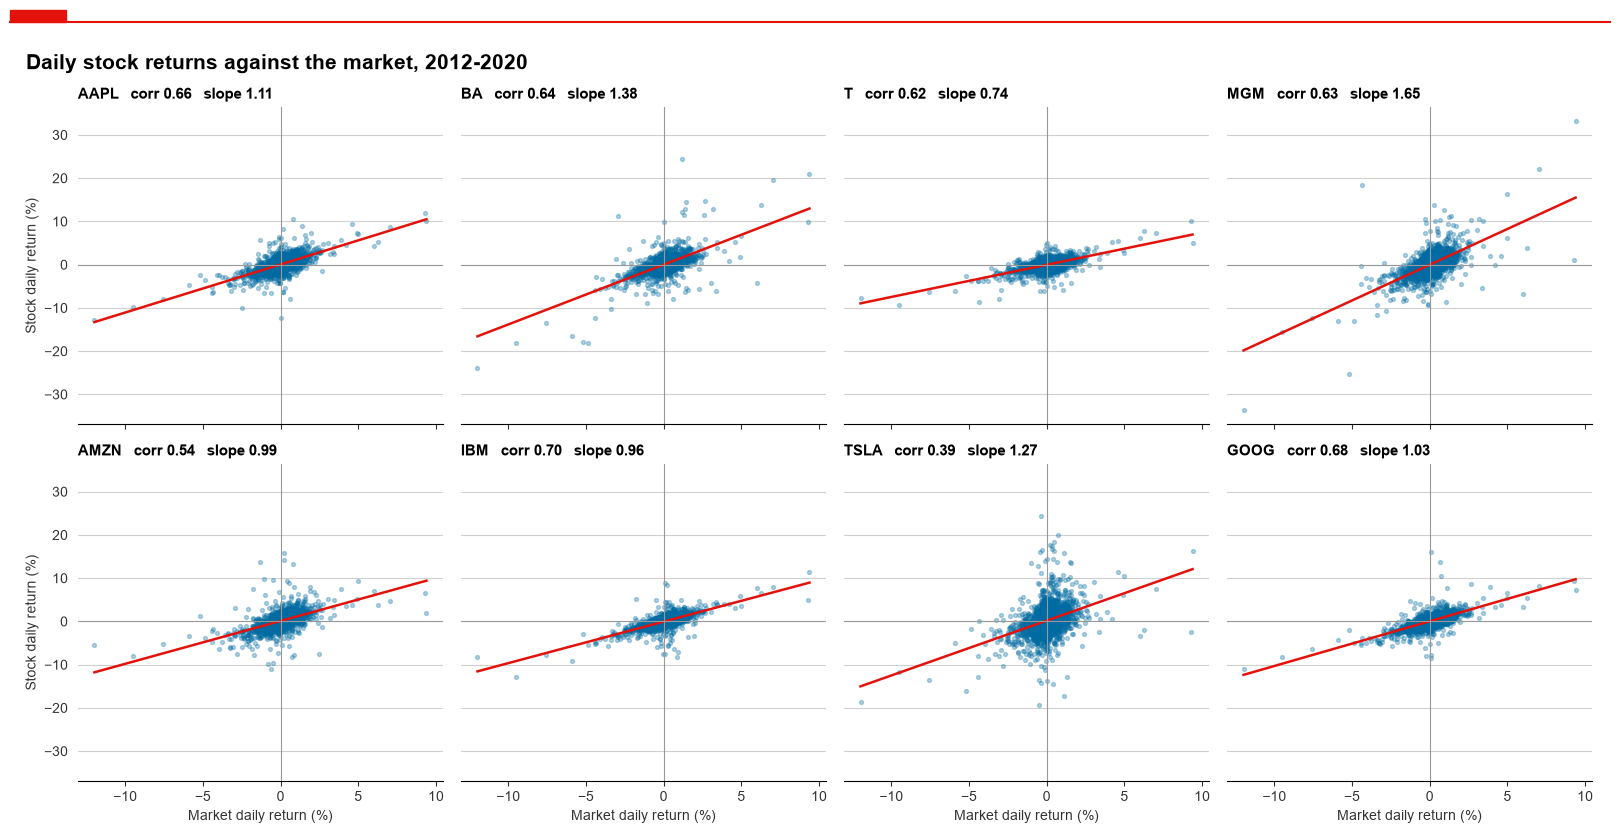

In [82]:
def plot_return_scatter(stock_returns, market_returns, title):
    '''One scatter per stock against the market, with the fitted line.'''
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

    for ax, stock in zip(axes.flat, stock_returns.columns):
        x, y = market_returns * 100, stock_returns[stock] * 100
        intercept, slope = ols(y, x).params
        grid = np.linspace(x.min(), x.max(), 50)

        ax.scatter(x, y, s=8, alpha=0.3, color=ECONOMIST_COLORS[0])
        ax.plot(grid, intercept + slope * grid, color=ECONOMIST_RED, lw=1.8)
        ax.axhline(0, color="#999999", lw=0.8)
        ax.axvline(0, color="#999999", lw=0.8)
        ax.set_title(f"{stock}   corr {x.corr(y):.2f}   slope {slope:.2f}", fontsize=11)
        ax.grid(False, axis="x")

    for ax in axes[1]:
        ax.set_xlabel("Market daily return (%)")
    for ax in axes[:, 0]:
        ax.set_ylabel("Stock daily return (%)")

    fig.suptitle(title, x=0.01, ha="left", fontsize=15, fontweight="bold")
    show()


plot_return_scatter(stock_returns, market_returns, "Daily stock returns against the market, 2012-2020")

In [83]:
market_correlation = stock_returns.corrwith(market_returns)

pd.DataFrame({                                       # beta = corr * sigma_i / sigma_M
    "correlation with market": market_correlation,
    "R2 (variance explained)": market_correlation ** 2,
    "annual volatility": stock_returns.std() * np.sqrt(DAYS),
    "sigma_i / sigma_M": stock_returns.std() / market_returns.std(),
}).sort_values("correlation with market", ascending=False)

,correlation with market,R2 (variance explained),annual volatility,sigma_i / sigma_M
IBM,0.7039,0.4955,0.2272,1.3644
GOOG,0.6846,0.4686,0.2518,1.5117
AAPL,0.6573,0.4321,0.2820,1.6931
BA,0.6418,0.4119,0.3588,2.1546
MGM,0.6314,0.3987,0.4361,2.6187
T,0.6175,0.3813,0.2008,1.2060
AMZN,0.5396,0.2911,0.3061,1.8380
TSLA,0.3879,0.1505,0.5446,3.2703


**Comments – Task #1**
- The association is positive for all eight stocks, with correlations between 0.39 and 0.70. This is consistent with a common factor affecting all returns, which is the premise of the CAPM.
- Correlations are highest for IBM (0.70), Google (0.69) and Apple (0.66), and lowest for Tesla (0.39) and Amazon (0.54).
- Expressed as $R^2$, the market accounts for 50% of the daily variance of IBM and 15% of that of Tesla. The remainder is firm-specific and, under the model, not priced.
- Correlation and slope need not coincide. MGM shows a moderate correlation (0.63) but the steepest slope (1.65), since $\sigma_i/\sigma_M = 2.6$; it is the slope that the model prices.
- Dispersion widens in the tails of the market return, and the observations of March 2020 are influential in every panel.

## Task #2 – Compute alpha and beta
### 2.1 The regression
With $r_f = 0$, the regression and its OLS estimators are

$$r_{i,t} = \alpha_i + \beta_i\, r_{M,t} + \varepsilon_{i,t}, \qquad
\hat\beta_i = \frac{\operatorname{Cov}(r_i, r_M)}{\operatorname{Var}(r_M)}, \qquad
\hat\alpha_i = \bar r_i - \hat\beta_i\, \bar r_M .$$

Estimation is carried out with `statsmodels`. Since daily returns display conditional heteroskedasticity and mild serial correlation, Newey-West (1987) standard errors with 8 lags are reported alongside the classical ones; the lag length follows the conventional $4(T/100)^{2/9}$ rule. Two restrictions are of interest: $\alpha_i = 0$, which the model implies, and $\beta_i = 1$. A test of $\beta_i = 0$ carries little economic content.

In [84]:
def capm_regressions(stock_returns, market_returns, hac_lags=HAC_LAGS):
    '''CAPM regression per stock, with classical and Newey-West standard errors.'''
    estimates, residuals = {}, {}

    for stock in stock_returns.columns:
        classical = ols(stock_returns[stock], market_returns)
        robust = ols(stock_returns[stock], market_returns, hac_lags=hac_lags)
        alpha, beta = classical.params

        estimates[stock] = {"alpha (p.a.)": alpha * DAYS, "se(alpha p.a.) HAC": robust.bse[0] * DAYS,
                            "t(alpha)": classical.tvalues[0], "t(alpha) HAC": robust.tvalues[0],
                            "p(alpha) HAC": robust.pvalues[0],
                            "beta": beta, "se(beta) HAC": robust.bse[1], "t(beta)": classical.tvalues[1],
                            "t(beta = 1)": (beta - 1) / classical.bse[1],
                            "t(beta = 1) HAC": (beta - 1) / robust.bse[1],
                            "R2": classical.rsquared}
        residuals[stock] = pd.Series(classical.resid, index=stock_returns.index)

    return pd.DataFrame(estimates).T, pd.DataFrame(residuals)


ESTIMATES = ["alpha (p.a.)", "t(alpha)", "t(alpha) HAC", "beta",
             "se(beta) HAC", "t(beta = 1)", "t(beta = 1) HAC", "R2"]

capm, residuals = capm_regressions(stock_returns, market_returns)
capm.sort_values("beta", ascending=False)[ESTIMATES]        # the frame also holds the standard errors used by the chart

,alpha (p.a.),t(alpha),t(alpha) HAC,beta,se(beta) HAC,t(beta = 1),t(beta = 1) HAC,R2
MGM,-0.0426,-0.3679,-0.3883,1.6536,0.0662,14.9450,9.8674,0.3987
BA,-0.0058,-0.0613,-0.0586,1.3829,0.0828,10.7597,4.6218,0.4119
TSLA,0.4433,2.5809,2.5978,1.2686,0.0874,4.1379,3.0749,0.1505
AAPL,0.1331,1.8312,1.7476,1.1129,0.0340,4.1083,3.3223,0.4321
GOOG,0.0841,1.3392,1.4293,1.0349,0.0434,1.4698,0.8037,0.4686
AMZN,0.2577,2.9222,2.9436,0.9917,0.1023,-0.2481,-0.0808,0.2911
IBM,-0.1348,-2.4405,-2.5731,0.9604,0.0296,-1.8967,-1.3370,0.4955
T,-0.0720,-1.3322,-1.3294,0.7446,0.0339,-12.5000,-7.5293,0.3813


In [85]:
print("Beta equals Cov(r_i, r_M) / Var(r_M):",
      np.allclose(returns.cov()[MARKET][stocks] / market_returns.var(), capm["beta"]))
print("Largest deviation from the betas estimated on the dividend-adjusted Yahoo series:",
      round(max(abs(estimate_beta(web_returns.loc[common_days, s], market_returns.loc[common_days]) - capm.loc[s, "beta"])
                for s in stocks), 4))

Beta equals Cov(r_i, r_M) / Var(r_M): True
Largest deviation from the betas estimated on the dividend-adjusted Yahoo series: 0.0043


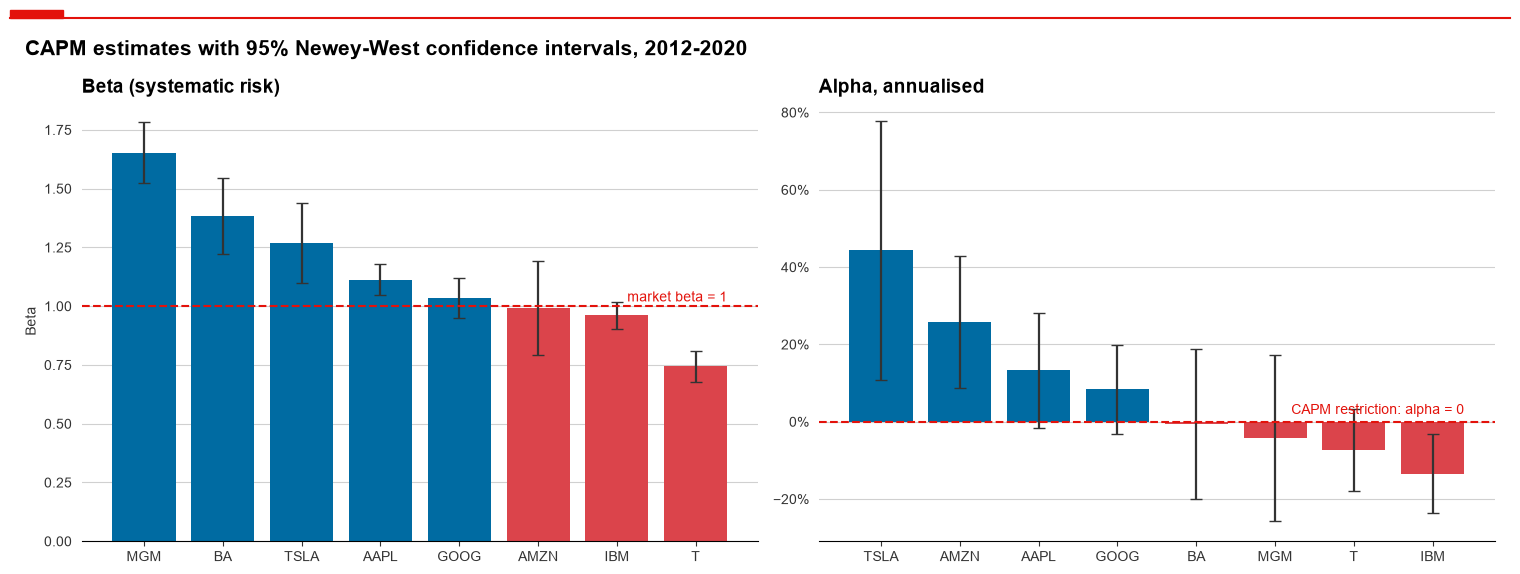

Alpha different from 0 at 5% (HAC): ['AMZN', 'IBM', 'TSLA']
Beta different from 1 at 5% (HAC) : ['AAPL', 'BA', 'T', 'MGM', 'TSLA']


In [86]:
def plot_alpha_beta(capm):
    '''Betas and annualised alphas with 95% Newey-West intervals; red = below the CAPM benchmark.'''
    panels = [("beta", "se(beta) HAC", 1, "Beta (systematic risk)", "market beta = 1"),
              ("alpha (p.a.)", "se(alpha p.a.) HAC", 0, "Alpha, annualised", "CAPM restriction: alpha = 0")]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    for ax, (column, standard_error, reference, title, note) in zip(axes, panels):
        values = capm[column].sort_values(ascending=False)
        ax.bar(values.index, values, yerr=1.96 * capm.loc[values.index, standard_error], capsize=4, ecolor="#333333",
               color=[ECONOMIST_COLORS[0] if v > reference else ECONOMIST_COLORS[8] for v in values])
        ax.axhline(reference, color=ECONOMIST_RED, lw=1.5, ls="--")
        ax.text(7.4, reference + 0.02, note, color=ECONOMIST_RED, ha="right", fontsize=10)
        ax.set_title(title)
        ax.grid(False, axis="x")

    axes[0].set_ylabel("Beta")
    axes[1].yaxis.set_major_formatter(PercentFormatter(1))
    fig.suptitle("CAPM estimates with 95% Newey-West confidence intervals, 2012-2020", x=0.01, ha="left", fontsize=15, fontweight="bold")
    show()


plot_alpha_beta(capm)

print("Alpha different from 0 at 5% (HAC):", list(capm.index[capm["p(alpha) HAC"] < 0.05]))
print("Beta different from 1 at 5% (HAC) :", list(capm.index[capm["t(beta = 1) HAC"].abs() > 1.96]))

**Comments – Task #2 (estimates and significance)**
- Against the null $\beta_i = 1$, the estimates for MGM (1.65), Boeing (1.38), Tesla (1.27) and Apple (1.11) lie significantly above unity and that for AT&T (0.74) significantly below; for Amazon, IBM and Google the null cannot be rejected. Classical and Newey-West inference agree on all eight stocks.
- The alpha estimates are largely insignificant, as the model implies. Only Amazon (+25.8% p.a.), Tesla (+44.3%) and IBM (−13.5%) reject at the 5% level, and Apple (+13.3%) at the 10% level.
- The ordering is economically plausible: MGM operates casinos and hotels, with operating and financial leverage on discretionary consumption, whereas AT&T is a regulated telecommunications firm with subscription revenue. The alpha estimates should nevertheless be interpreted with caution, since the interval around Tesla's is approximately ±34 pp and the eight firms were not selected at random.
- The Newey-West correction affects beta considerably more than alpha. The alpha $t$-statistics change by less than 0.15, while the beta standard errors increase by a factor of 1.2 to 3.1 (Amazon 3.1, Boeing 2.3). No inference changes, but the interval for Amazon's beta is 0.79 to 1.19 rather than 0.93 to 1.06.
- The stocks with the largest alphas (Tesla, Amazon) are not those with the largest betas, and IBM combines an average beta with the most negative alpha. Task #3 examines the relation out of sample.

### 2.2 The error terms
The residual $\varepsilon_{i,t} = r_{i,t} - (\hat\alpha_i + \hat\beta_i r_{M,t})$ measures the firm-specific component of returns. By construction it has zero mean and is orthogonal to the market return, so the quantities of interest are its distribution and its magnitude.

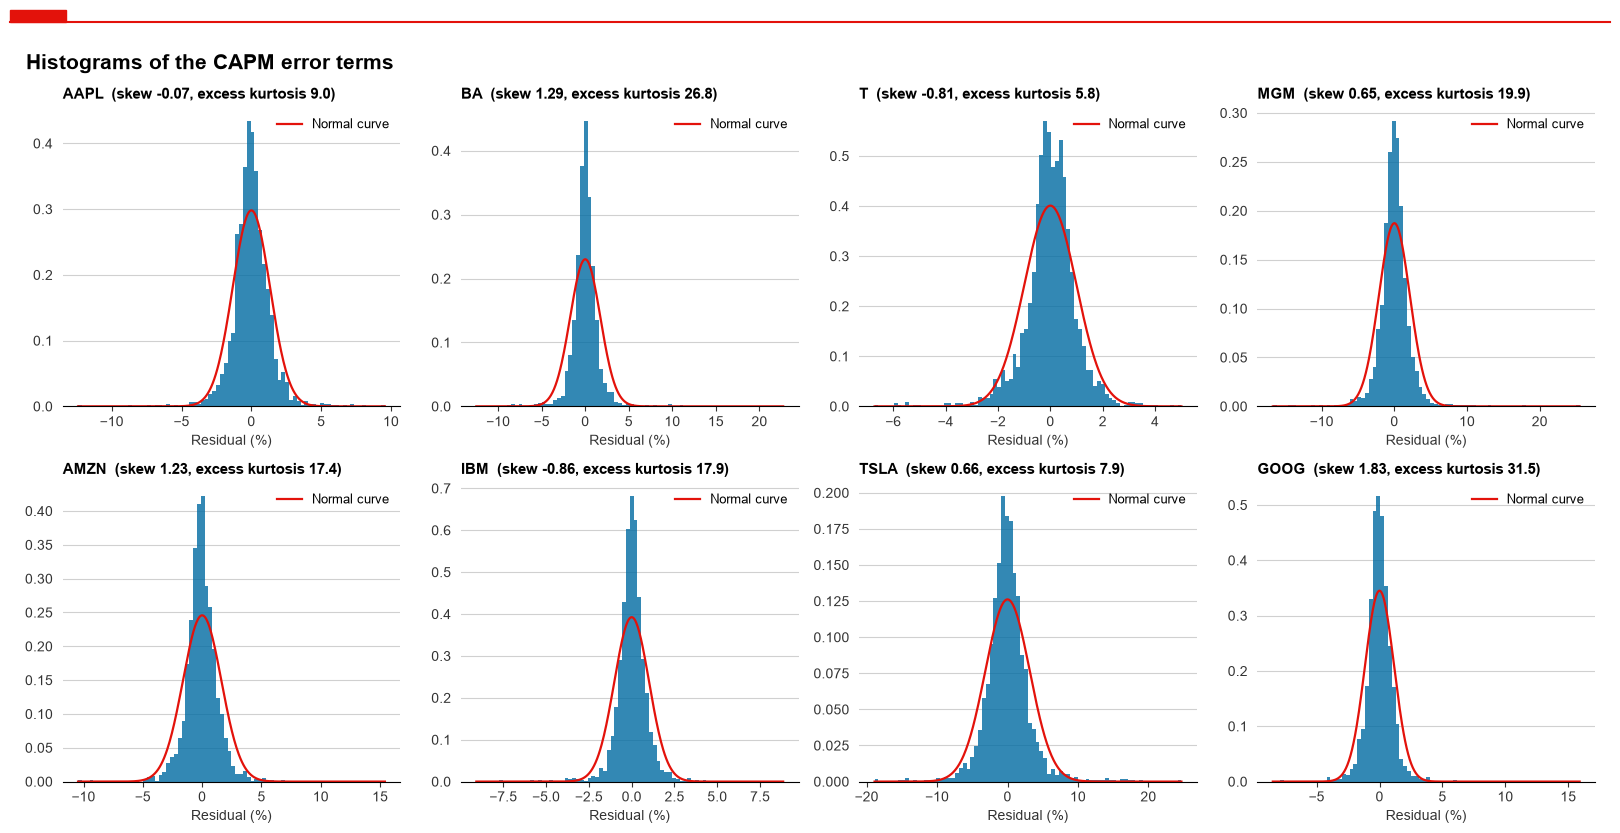

In [87]:
def plot_residual_histograms(residuals):
    '''Histogram of each stock's error term, with a normal curve of the same mean and standard deviation.'''
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for ax, stock in zip(axes.flat, residuals.columns):
        e = residuals[stock] * 100
        grid = np.linspace(e.min(), e.max(), 400)
        ax.hist(e, bins=80, density=True, color=ECONOMIST_COLORS[0], alpha=0.8)
        ax.plot(grid, stats.norm.pdf(grid, e.mean(), e.std()), color=ECONOMIST_RED, label="Normal curve")
        ax.set_title(f"{stock}  (skew {e.skew():.2f}, excess kurtosis {e.kurt():.1f})", fontsize=11)
        ax.set_xlabel("Residual (%)")
        ax.legend(fontsize=9)

    fig.suptitle("Histograms of the CAPM error terms", x=0.01, ha="left", fontsize=15, fontweight="bold")
    show()


plot_residual_histograms(residuals)

In [88]:
def residual_table(residuals):
    '''Size and shape of the error terms, with each stock's largest residual and its date.'''
    jb = residuals.apply(lambda e: pd.Series(stats.jarque_bera(e), index=["JB", "p(JB)"]))
    worst_day = residuals.abs().idxmax()

    return pd.DataFrame({
        "idiosyncratic vol (p.a.)": residuals.std() * np.sqrt(DAYS),
        "share of total vol": residuals.std() / stock_returns.std(),
        "skewness": residuals.skew(),
        "excess kurtosis": residuals.kurt(),
        "p(JB)": jb.loc["p(JB)"],
        "largest residual": [residuals[s][worst_day[s]] for s in residuals.columns],
        "on": [worst_day[s].date() for s in residuals.columns],
    }).sort_values("idiosyncratic vol (p.a.)", ascending=False)


residual_table(residuals)

,idiosyncratic vol (p.a.),share of total vol,skewness,excess kurtosis,p(JB),largest residual,on
TSLA,0.5020,0.9217,0.6639,7.9381,0.0000,0.2469,2013-05-09
MGM,0.3382,0.7754,0.6526,19.8832,0.0000,0.2550,2020-03-20
BA,0.2752,0.7669,1.2928,26.7771,0.0000,0.2273,2020-03-25
AMZN,0.2577,0.8419,1.2256,17.3880,0.0000,0.1540,2012-04-27
AAPL,0.2125,0.7536,-0.0681,9.0496,0.0000,-0.1241,2013-01-24
GOOG,0.1835,0.7289,1.8252,31.4961,0.0000,0.1590,2015-07-17
IBM,0.1614,0.7103,-0.8628,17.9319,0.0000,-0.0908,2013-04-19
T,0.1580,0.7866,-0.8131,5.7792,0.0000,-0.0671,2018-04-26


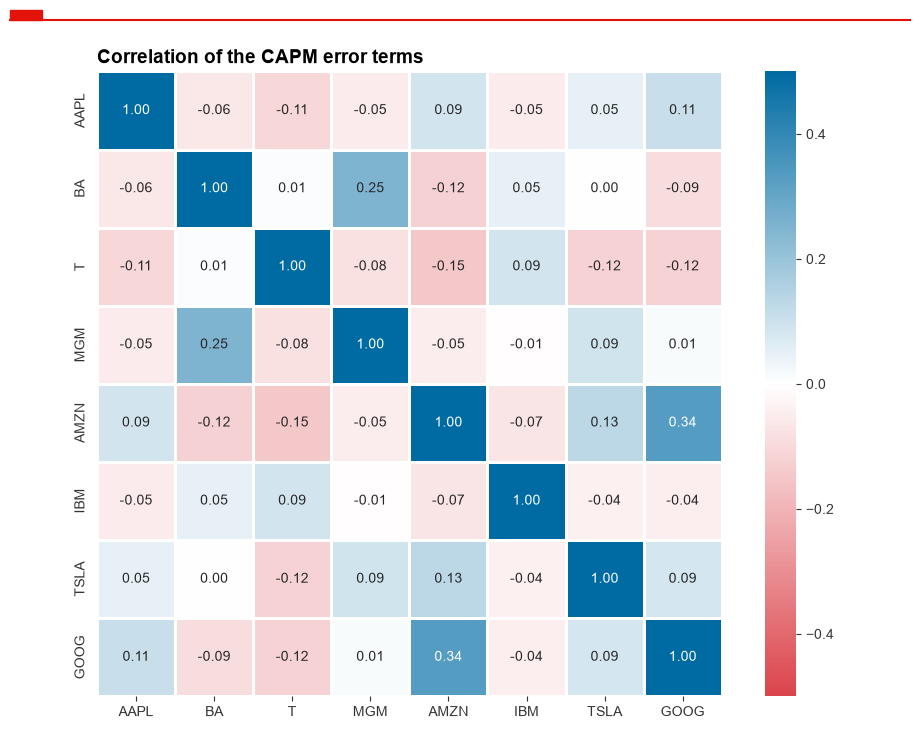

In [89]:
# Under the CAPM the error terms are purely firm-specific, hence uncorrelated across stocks.
plt.figure(figsize=(9, 7))
sns.heatmap(residuals.corr(), annot=True, fmt=".2f", cmap=ECONOMIST_DIVERGING, vmin=-0.5, vmax=0.5, square=True, linewidths=1)
plt.title("Correlation of the CAPM error terms")
plt.grid(False)
show()

**Comments – Task #2 (error terms)**
- The residual distributions are bell-shaped but not normal: excess kurtosis ranges from 5.8 (AT&T) to 31.4 (Google), and the Jarque-Bera test rejects normality for all eight series ($p \approx 0$). Removing the market factor therefore does not remove the fat tails documented in PC Lab #1.
- Idiosyncratic volatility is substantial: 50% p.a. for Tesla, 34% for MGM and 16% for AT&T and IBM, corresponding to 92% of Tesla's total volatility and 71% of IBM's. A single factor leaves most of the variance unexplained, which also accounts for the imprecision of the alpha estimates.
- The largest residuals correspond to firm-specific events rather than to market movements: Apple −12.4% on 24 January 2013, Tesla +24.7% on 9 May 2013, MGM +25.5% and Boeing +22.7% in March 2020.
- The residuals are not mutually uncorrelated (Amazon-Google 0.34, Boeing-MGM 0.25), which is inconsistent with a single-factor specification and motivates the joint test in §2.3.

### 2.3 Joint test: the GRS F-statistic
Testing the eight alphas separately ignores their cross-sectional dependence, documented in §2.2. Gibbons, Ross and Shanken (1989) propose a joint test based on the residual covariance matrix:

$$F = \frac{T\,(T-N-K)}{N\,(T-K-1)}\;\frac{\hat\alpha' \hat\Sigma^{-1} \hat\alpha}{1 + \widehat{SR}_M^{\,2}} \;\sim\; F(N,\; T-N-K).$$

The quadratic form $\hat\alpha' \hat\Sigma^{-1} \hat\alpha$ equals the increase in the squared Sharpe ratio obtained by adding the eight stocks to the market portfolio, which gives the statistic a direct economic interpretation.

In [90]:
def grs_test(residuals, market_returns, alphas):
    '''Gibbons-Ross-Shanken (1989) joint test that every alpha is zero.'''
    T, N, K = len(residuals), residuals.shape[1], 1                        # one factor
    alpha = alphas[residuals.columns].to_numpy()
    sigma = residuals.cov(ddof=0).to_numpy()                               # MLE residual covariance
    sharpe_market = market_returns.mean() / market_returns.std(ddof=0)

    added_sharpe_squared = alpha @ np.linalg.inv(sigma) @ alpha            # what the alphas add
    f_statistic = T * (T - N - K) / (N * (T - K - 1)) * added_sharpe_squared / (1 + sharpe_market ** 2)

    return pd.Series({
        "F": f_statistic,
        "degrees of freedom": f"({N}, {T - N - K})",
        "p-value": 1 - stats.f.cdf(f_statistic, N, T - N - K),
        "Sharpe ratio p.a., market": sharpe_market * np.sqrt(DAYS),
        "Sharpe ratio p.a., tangency": np.sqrt(sharpe_market ** 2 + added_sharpe_squared) * np.sqrt(DAYS),
    })


daily_alphas = capm["alpha (p.a.)"] / DAYS

pd.DataFrame({"all 8 stocks": grs_test(residuals, market_returns, daily_alphas),
              "without TSLA": grs_test(residuals.drop(columns="TSLA"), market_returns, daily_alphas),
              "without TSLA and AMZN": grs_test(residuals.drop(columns=["TSLA", "AMZN"]), market_returns, daily_alphas)})

,all 8 stocks,without TSLA,without TSLA and AMZN
F,2.5944,2.3534,1.8235
degrees of freedom,"(8, 2149)","(7, 2150)","(6, 2151)"
p-value,0.0080,0.0215,0.0908
"Sharpe ratio p.a., market",0.7468,0.7468,0.7468
"Sharpe ratio p.a., tangency",1.7305,1.5783,1.3569


**Comments – Task #2 (joint test)**
- The statistic is $F = 2.59$ with $(8, 2149)$ degrees of freedom and $p = 0.008$, so the joint restriction is rejected at the 1% level.
- In Sharpe-ratio terms, the market portfolio attains 0.75 p.a. and the ex-post tangency portfolio of the market and the eight stocks 1.73, which is of the same order as the 1.50 obtained by the optimiser in PC Lab #1.
- The rejection is not uniform across assets: excluding Tesla yields $p = 0.022$ and excluding Amazon as well $p = 0.091$. Since the test assumes i.i.d. normal errors, which §2.2 rejects, the exact $p$-value should be read as indicative; a GMM-based or bootstrapped version would be the appropriate robust analogue.

### 2.4 An equally weighted high-risk portfolio
The task asks for the four riskiest assets over the full period, equally weighted, with the expected return implied by $\hat\beta$ and $\bar r_M$. Risk is measured by beta, since only systematic risk is priced under the model; the ranking by total volatility, which replaces Apple with Amazon, is reported for comparison. Beta is linear in the weights, so $\beta_p = \sum_i w_i \beta_i$ and, with $r_f = 0$, $E[r_p] = \beta_p\,\bar r_M$.

In [91]:
def portfolio_capm(weights, stock_returns, market_returns, betas):
    '''CAPM prediction and realised performance of a portfolio.'''
    portfolio_returns = stock_returns[weights.index] @ weights
    beta = betas[weights.index] @ weights                      # beta is linear in the weights
    market_mean, realised = market_returns.mean() * DAYS, portfolio_returns.mean() * DAYS
    volatility = portfolio_returns.std() * np.sqrt(DAYS)

    return pd.Series({
        "portfolio beta": beta,
        "CAPM expected return": RF + beta * (market_mean - RF),
        "realised return": realised,
        "alpha (realised - predicted)": realised - beta * market_mean,
        "volatility": volatility,
        "systematic vol (beta * sigma_M)": beta * market_returns.std() * np.sqrt(DAYS),
        "Sharpe ratio": realised / volatility,
    }), portfolio_returns


riskiest_by_beta = capm["beta"].nlargest(4).index
riskiest_by_vol = (stock_returns.std() * np.sqrt(DAYS)).nlargest(4).index
print("Four riskiest by beta      :", list(riskiest_by_beta))
print("Four riskiest by volatility:", list(riskiest_by_vol))

weights = {"EW top-4 beta": pd.Series(0.25, index=riskiest_by_beta),
           "EW top-4 volatility": pd.Series(0.25, index=riskiest_by_vol),
           "EW all 8 stocks": pd.Series(1 / len(stocks), index=stocks)}

statistics, portfolio_returns = {}, {}
for name, w in weights.items():
    statistics[name], portfolio_returns[name] = portfolio_capm(w, stock_returns, market_returns, capm["beta"])
statistics["Market"], portfolio_returns["Market"] = portfolio_capm(pd.Series({MARKET: 1.0}), returns, market_returns, pd.Series({MARKET: 1.0}))

pd.DataFrame(statistics)

Four riskiest by beta      : ['MGM', 'BA', 'TSLA', 'AAPL']
Four riskiest by volatility: ['TSLA', 'MGM', 'BA', 'AMZN']


,EW top-4 beta,EW top-4 volatility,EW all 8 stocks,Market
portfolio beta,1.3545,1.3242,1.1437,1.0000
CAPM expected return,0.1684,0.1646,0.1422,0.1243
realised return,0.3004,0.3278,0.2251,0.1243
alpha (realised - predicted),0.1320,0.1632,0.0829,0.0000
volatility,0.2932,0.2930,0.2178,0.1665
systematic vol (beta * sigma_M),0.2256,0.2205,0.1905,0.1665
Sharpe ratio,1.0246,1.1188,1.0334,0.7466


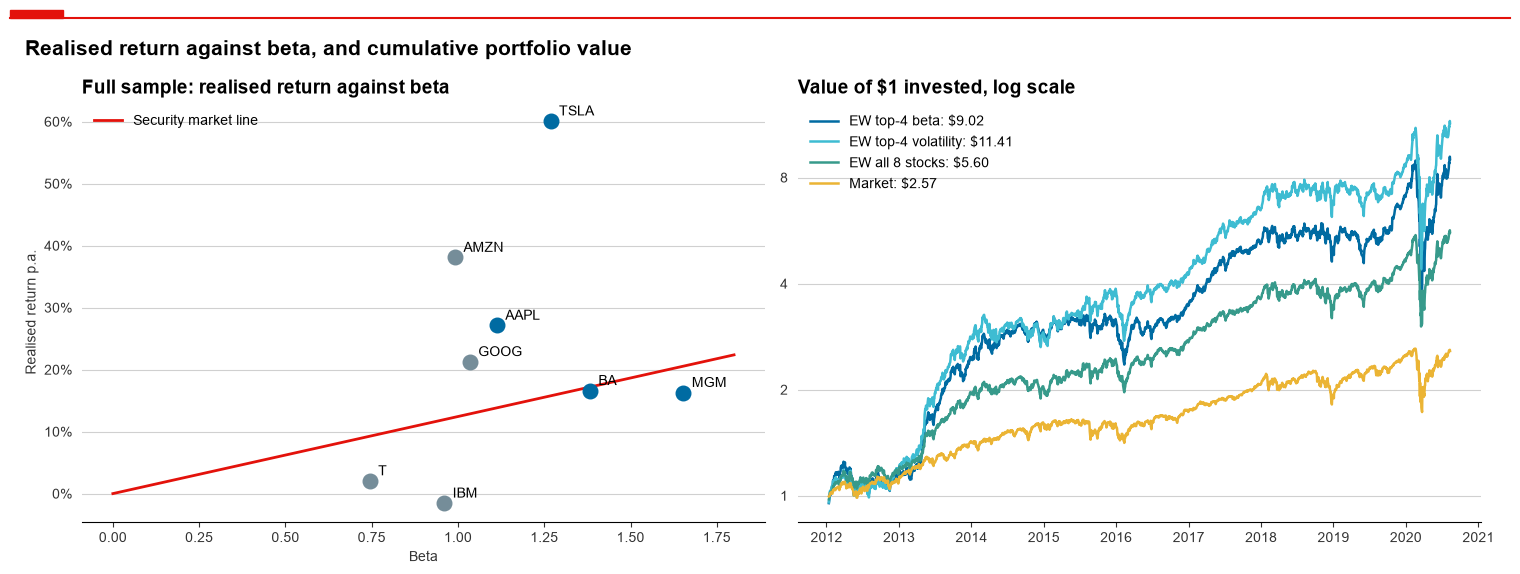

In [92]:
def plot_boss_portfolio(capm, stock_returns, market_returns, portfolio_returns, selection):
    '''Left: realised return against beta, stock by stock. Right: what $1 would have become.'''
    market_mean, realised = market_returns.mean() * DAYS, stock_returns.mean() * DAYS
    growth = (1 + pd.DataFrame(portfolio_returns)).cumprod()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    axes[0].plot([0, 1.8], [0, 1.8 * market_mean], color=ECONOMIST_RED, lw=2, label="Security market line")
    for stock in capm.index:
        point = (capm.loc[stock, "beta"], realised[stock])
        axes[0].scatter(*point, s=110, zorder=3, color=ECONOMIST_COLORS[0] if stock in selection else ECONOMIST_COLORS[7])
        axes[0].annotate(stock, point, xytext=(6, 4), textcoords="offset points", fontsize=10)
    axes[0].set_xlabel("Beta")
    axes[0].set_ylabel("Realised return p.a.")
    axes[0].set_title("Full sample: realised return against beta")
    axes[0].yaxis.set_major_formatter(PercentFormatter(1))
    axes[0].legend(loc="upper left")

    axes[1].plot(growth, lw=1.8)
    axes[1].set_yscale("log")
    axes[1].set_yticks([1, 2, 4, 8], labels=["1", "2", "4", "8"])
    axes[1].minorticks_off()
    axes[1].set_title("Value of $1 invested, log scale")
    axes[1].legend([f"{name}: ${growth[name].iloc[-1]:.2f}" for name in growth], loc="upper left")

    for ax in axes:
        ax.grid(False, axis="x")

    fig.suptitle("Realised return against beta, and cumulative portfolio value", x=0.01, ha="left", fontsize=15, fontweight="bold")
    show()


plot_boss_portfolio(capm, stock_returns, market_returns, portfolio_returns, list(riskiest_by_beta))

**Comments – Task #2 (the high-risk portfolio)**
- The four highest betas give $\beta_p = 1.35$, which coincides with the beta estimated on the portfolio's own return series.
- The implied expected return is $1.35 \times 12.4\% = 16.8\%$ p.a., against a realised 30.0%. The difference of 13.2 pp is the average of the four alphas and is driven by Tesla; one dollar invested at the start of the sample grows to \$9.02, against \$2.57 for the index.
- The additional risk is certain while the additional return is not: portfolio volatility is 29.3% against 16.7% for the market, of which $\beta_p\sigma_M = 22.6\%$ is systematic and 18.7% idiosyncratic and hence unpriced under the model.
- Concentration provides no risk-adjusted improvement. The equally weighted portfolio of all eight stocks has beta 1.14, volatility 21.8%, a terminal value of \$5.60 and essentially the same Sharpe ratio (1.03 against 1.02). Selection by volatility rather than beta leads to similar conclusions (beta 1.32, realised 32.8%).
- The prediction uses the realised sample mean of a period of rising markets. Task #3 assesses the out-of-sample content of the relation.

## Task #3 – Testing the CAPM theory
Task #2 estimates and evaluates the model on the same observations, so its fit is uninformative about predictive content. The CAPM is a statement about expected returns, which suggests the following design:

1. at the end of year $y-1$, estimate $\beta_i^{\,y-1}$ on the preceding 252 trading days;
2. form the prediction $\hat r_i^{\,y} = r_f + \beta_i^{\,y-1}(\bar r_M^{\,y} - r_f) = \beta_i^{\,y-1}\,\bar r_M^{\,y}$, using the market return realised in year $y$;
3. compare it with the realised annualised return $\bar r_i^{\,y}$.

Because step 2 supplies the realised market return, the exercise tests only whether beta explains the cross-section of returns. Under the model the observations lie on the security market line, with slope $\bar r_M^{\,y}$ and zero intercept. The test covers 2013 to 2020; the 2013 beta uses the 242 trading days available in 2012, and 2020 ends on 11 August.

In [93]:
def capm_panel(stock_returns, market_returns, years, window=WINDOW):
    '''One row per stock and year: beta from before the year, CAPM prediction, realised return.'''
    rows = []

    for year in years:
        past_market = market_returns.loc[:f"{year - 1}-12-31"].tail(window)       # estimation window
        market_mean = market_returns.loc[str(year)].mean() * DAYS                 # the year being predicted

        for stock in stock_returns.columns:
            beta = estimate_beta(stock_returns[stock].loc[past_market.index], past_market)
            rows.append({"year": year, "stock": stock, "beta": beta, "market return": market_mean,
                         "predicted": RF + beta * (market_mean - RF),
                         "realised": stock_returns[stock].loc[str(year)].mean() * DAYS,
                         "days used": len(past_market)})

    panel = pd.DataFrame(rows)
    panel["error"] = panel["realised"] - panel["predicted"]                       # realised alpha
    return panel


panel = capm_panel(stock_returns, market_returns, years=range(2013, 2021))
print("Estimation days per year:", panel.groupby("year")["days used"].first().to_dict())
panel.head(8)

Estimation days per year: {2013: 242, 2014: 252, 2015: 252, 2016: 252, 2017: 252, 2018: 252, 2019: 252, 2020: 252}


,year,stock,beta,market return,predicted,realised,days used,error
0,2013,AAPL,1.2830,0.2655,0.3407,0.0941,242,-0.2466
1,2013,BA,1.0246,0.2655,0.2721,0.6170,242,0.3450
2,2013,T,0.6163,0.2655,0.1636,0.0543,242,-0.1093
3,2013,MGM,1.7327,0.2655,0.4601,0.7469,242,0.2868
4,2013,AMZN,1.1231,0.2655,0.2982,0.5001,242,0.2019
5,2013,IBM,0.8566,0.2655,0.2275,-0.0034,242,-0.2308
6,2013,TSLA,1.6114,0.2655,0.4279,1.7184,242,1.2905
7,2013,GOOG,0.8603,0.2655,0.2284,0.4836,242,0.2552


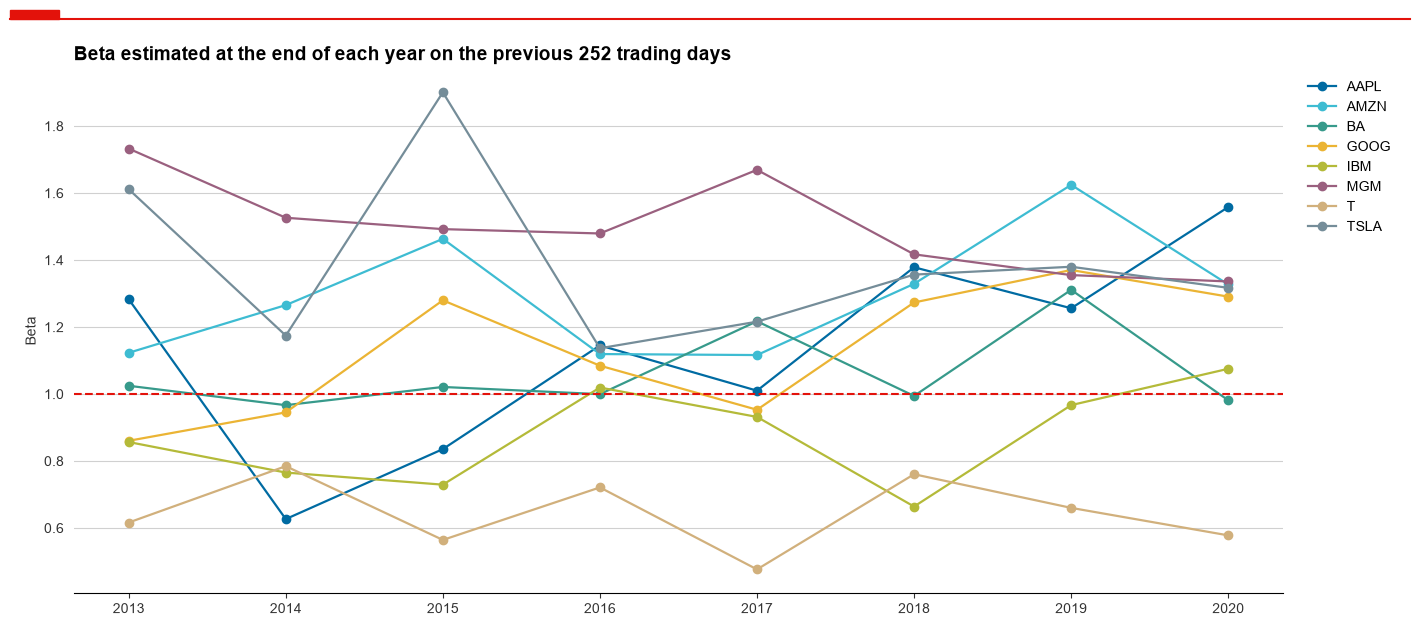

Correlation between consecutive yearly betas: 0.65


stock,AAPL,AMZN,BA,GOOG,IBM,MGM,T,TSLA
year,,,,,,,,
2013,1.2800,1.1200,1.0200,0.8600,0.8600,1.7300,0.6200,1.6100
2014,0.6300,1.2700,0.9700,0.9500,0.7700,1.5300,0.7800,1.1700
2015,0.8400,1.4600,1.0200,1.2800,0.7300,1.4900,0.5600,1.9000
2016,1.1500,1.1200,1.0000,1.0800,1.0200,1.4800,0.7200,1.1400
2017,1.0100,1.1200,1.2200,0.9500,0.9300,1.6700,0.4800,1.2200
2018,1.3800,1.3300,0.9900,1.2700,0.6600,1.4200,0.7600,1.3600
2019,1.2600,1.6200,1.3100,1.3700,0.9700,1.3600,0.6600,1.3800
2020,1.5600,1.3300,0.9800,1.2900,1.0800,1.3400,0.5800,1.3200


In [94]:
# Stability of the beta estimate that would have been available at the time
betas_by_year = panel.pivot(index="year", columns="stock", values="beta")

ax = betas_by_year.plot(figsize=(14, 6), marker="o")
ax.axhline(1, color=ECONOMIST_RED, lw=1.5, ls="--")
ax.set_title("Beta estimated at the end of each year on the previous 252 trading days")
ax.set_xlabel("")
ax.set_ylabel("Beta")
ax.grid(False, axis="x")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
show()

print(f"Correlation between consecutive yearly betas: {np.corrcoef(betas_by_year.iloc[:-1].to_numpy().ravel(), betas_by_year.iloc[1:].to_numpy().ravel())[0, 1]:.2f}")
betas_by_year.round(2)

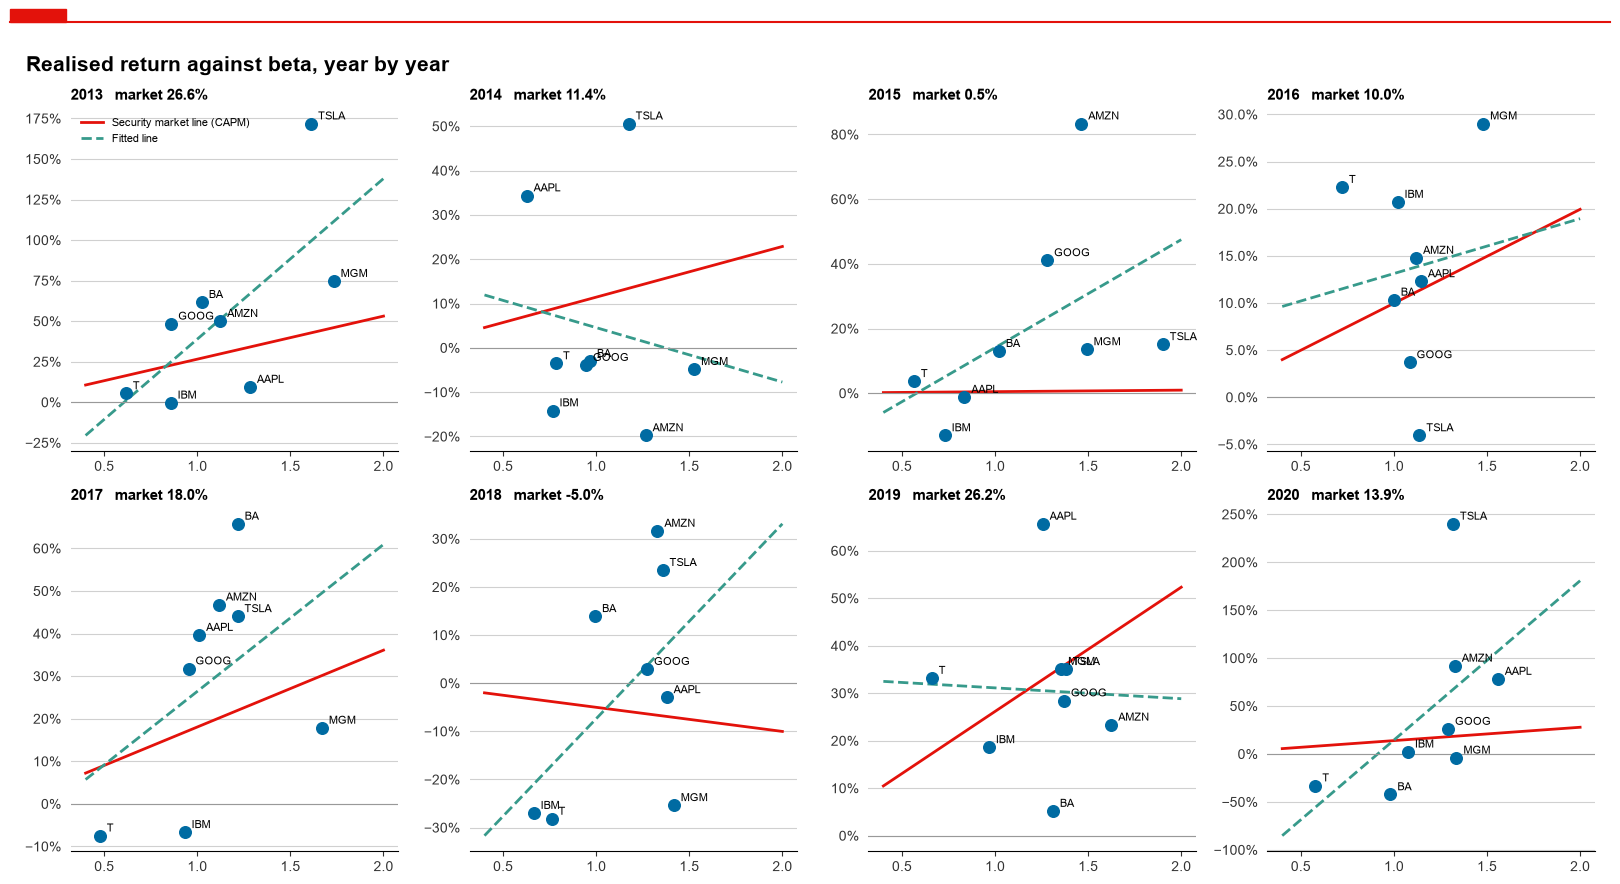

In [95]:
def plot_yearly_sml(panel):
    '''One panel per year: realised returns against last year's beta, with the security market line.'''
    fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
    grid = np.linspace(0.4, 2.0, 20)

    for ax, (year, year_data) in zip(axes.flat, panel.groupby("year")):
        market_mean = year_data["market return"].iloc[0]
        intercept, slope = ols(year_data["realised"], year_data["beta"]).params

        ax.plot(grid, RF + grid * (market_mean - RF), color=ECONOMIST_RED, lw=2)                # prediction
        ax.plot(grid, intercept + slope * grid, color=ECONOMIST_COLORS[2], lw=2, ls="--")       # outcome
        ax.scatter(year_data["beta"], year_data["realised"], s=70, color=ECONOMIST_COLORS[0], zorder=3)
        for _, row in year_data.iterrows():
            ax.annotate(row["stock"], (row["beta"], row["realised"]), xytext=(5, 3), textcoords="offset points", fontsize=8)

        ax.axhline(0, color="#999999", lw=0.8)
        ax.set_title(f"{year}   market {market_mean:.1%}", fontsize=11)
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.grid(False, axis="x")

    axes[0, 0].plot([], [], color=ECONOMIST_RED, lw=2, label="Security market line (CAPM)")
    axes[0, 0].plot([], [], color=ECONOMIST_COLORS[2], lw=2, ls="--", label="Fitted line")
    axes[0, 0].legend(fontsize=8, loc="upper left")

    fig.suptitle("Realised return against beta, year by year", x=0.01, ha="left", fontsize=15, fontweight="bold")
    show()


plot_yearly_sml(panel)

In [96]:
def cross_sectional_regressions(panel):
    '''Fama-MacBeth first stage: each year, the eight realised returns on the betas known at its start.'''
    rows = []

    for year, year_data in panel.groupby("year"):
        fit = ols(year_data["realised"], year_data["beta"])
        gamma0, gamma1 = fit.params
        rows.append({"year": year, "gamma0 (CAPM: 0)": gamma0, "gamma1 (CAPM: market return)": gamma1,
                     "market return": year_data["market return"].iloc[0],
                     "t(gamma1)": fit.tvalues[1], "p(gamma1)": fit.pvalues[1], "R2": fit.rsquared})

    return pd.DataFrame(rows).set_index("year")


cross_section = cross_sectional_regressions(panel)
cross_section.round(3)

,gamma0 (CAPM: 0),gamma1 (CAPM: market return),market return,t(gamma1),p(gamma1),R2
year,,,,,,
2013,-0.6010,0.9900,0.2660,2.3060,0.0610,0.4700
2014,0.1680,-0.1230,0.1140,-0.3690,0.7250,0.0220
2015,-0.1930,0.3340,0.0050,1.4150,0.2070,0.2500
2016,0.0730,0.0580,0.1000,0.2830,0.7860,0.0130
2017,-0.0810,0.3450,0.1800,1.2220,0.2680,0.1990
2018,-0.4790,0.4050,-0.0500,1.4600,0.1950,0.2620
2019,0.3340,-0.0230,0.2620,-0.0950,0.9270,0.0020
2020,-1.5170,1.6620,0.1390,1.5780,0.1660,0.2930


In [97]:
# Fama-MacBeth: average the yearly coefficients, t = mean / standard error of the mean
coefficients = cross_section[["gamma0 (CAPM: 0)", "gamma1 (CAPM: market return)", "market return"]]
summary = pd.DataFrame({"average": coefficients.mean(), "t-statistic": coefficients.mean() / coefficients.sem(),
                        "years positive": (coefficients > 0).sum()})
print("Fama-MacBeth over 2013-2020 (8 yearly cross-sections)")
display(summary.round(3))

pooled = ols(panel["realised"], panel["beta"])
print(f"Pooled over all 64 stock-years: intercept {pooled.params[0]:+.3f} (CAPM: 0), slope {pooled.params[1]:+.3f} "
      f"(CAPM: {panel['market return'].mean():.3f}), t(slope) {pooled.tvalues[1]:.2f}, R2 {pooled.rsquared:.3f}")

Fama-MacBeth over 2013-2020 (8 yearly cross-sections)


,average,t-statistic,years positive
gamma0 (CAPM: 0),-0.2870,-1.3800,3
gamma1 (CAPM: market return),0.4560,2.1620,6
market return,0.1270,3.2100,7


Pooled over all 64 stock-years: intercept -0.352 (CAPM: 0), slope +0.525 (CAPM: 0.127), t(slope) 3.21, R2 0.142


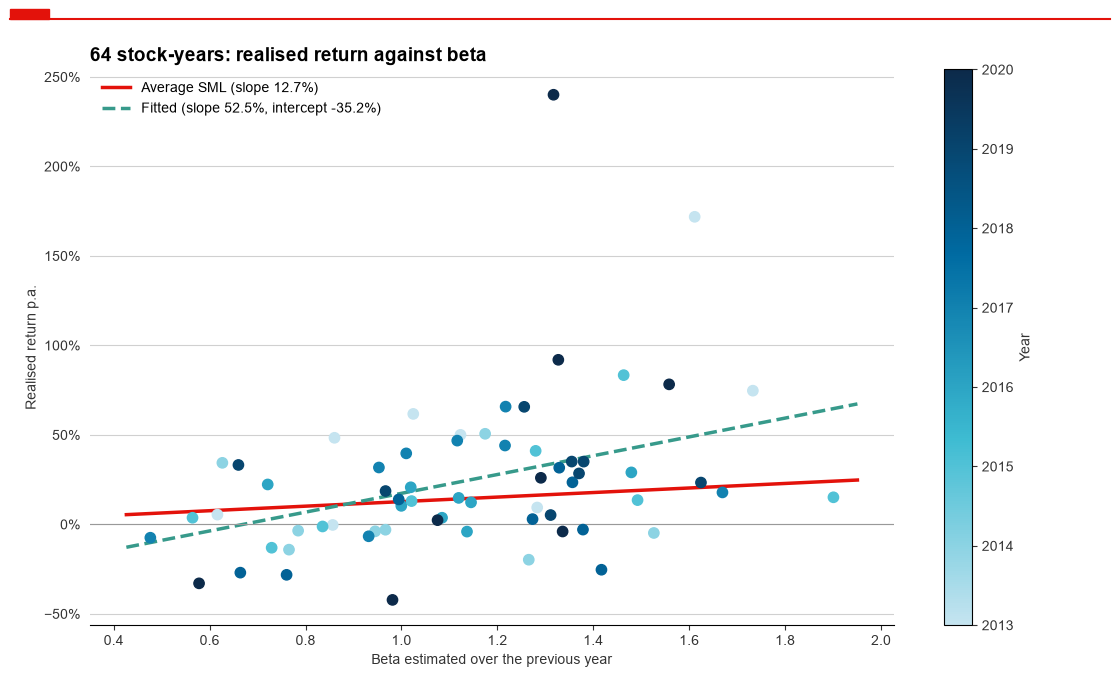

Mean absolute error of the annual forecast
  CAPM (beta x market)      : 26.3%
  Naive (the market return) : 27.0%
  Naive (zero)              : 31.8%


In [98]:
def plot_pooled_sml(panel):
    '''All 64 stock-years: realised return against the beta known before the year.'''
    market_mean = panel["market return"].mean()
    intercept, slope = ols(panel["realised"], panel["beta"]).params
    grid = np.linspace(panel["beta"].min() - 0.05, panel["beta"].max() + 0.05, 20)

    plt.figure(figsize=(11, 6.5))
    scatter = plt.scatter(panel["beta"], panel["realised"], c=panel["year"], cmap=ECONOMIST_BLUES, s=55, zorder=3)
    plt.plot(grid, RF + grid * (market_mean - RF), color=ECONOMIST_RED, lw=2.5, label=f"Average SML (slope {market_mean:.1%})")
    plt.plot(grid, intercept + slope * grid, color=ECONOMIST_COLORS[2], lw=2.5, ls="--",
             label=f"Fitted (slope {slope:.1%}, intercept {intercept:.1%})")
    plt.axhline(0, color="#999999", lw=0.8)
    plt.colorbar(scatter, label="Year")
    plt.xlabel("Beta estimated over the previous year")
    plt.ylabel("Realised return p.a.")
    plt.title("64 stock-years: realised return against beta")
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
    plt.grid(False, axis="x")
    plt.legend(loc="upper left")
    show()


plot_pooled_sml(panel)

print("Mean absolute error of the annual forecast")
print(f"  CAPM (beta x market)      : {panel['error'].abs().mean():.1%}")
print(f"  Naive (the market return) : {(panel['realised'] - panel['market return']).abs().mean():.1%}")
print(f"  Naive (zero)              : {panel['realised'].abs().mean():.1%}")

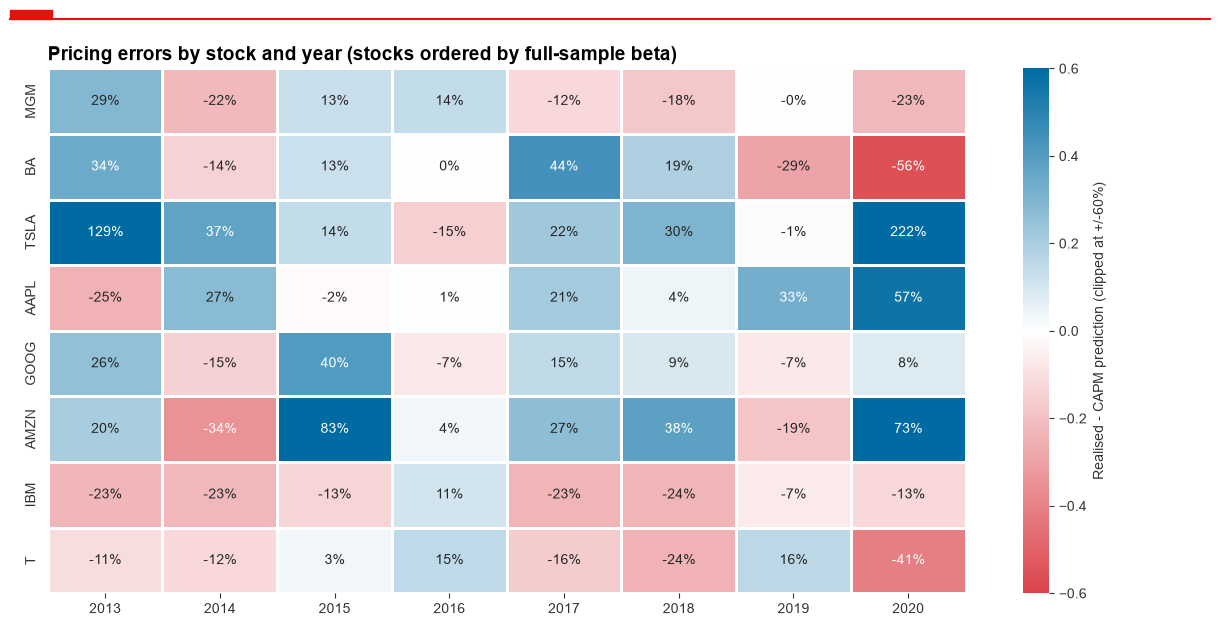

Average error per stock
stock
IBM     -14.4%
T        -8.8%
MGM      -2.5%
BA       +1.4%
GOOG     +8.6%
AAPL    +14.6%
AMZN    +23.9%
TSLA    +54.8%

Mean absolute error per year
year
2013    37.1%
2014    23.1%
2015    22.6%
2016     8.4%
2017    22.5%
2018    20.9%
2019    14.1%
2020    61.5%


In [99]:
# Pricing errors by stock and year; colours are clipped at +/-60% so that Tesla's +222% does not dominate the scale.
errors = panel.pivot(index="stock", columns="year", values="error").loc[capm["beta"].sort_values(ascending=False).index]

plt.figure(figsize=(12, 6))
sns.heatmap(errors, annot=True, fmt=".0%", cmap=ECONOMIST_DIVERGING, center=0, vmin=-0.6, vmax=0.6, linewidths=1,
            cbar_kws={"label": "Realised - CAPM prediction (clipped at +/-60%)"})
plt.title("Pricing errors by stock and year (stocks ordered by full-sample beta)")
plt.xlabel("")
plt.ylabel("")
plt.grid(False)
show()

print("Average error per stock")
print(panel.groupby("stock")["error"].mean().sort_values().map("{:+.1%}".format).to_string())
print("\nMean absolute error per year")
print(panel.groupby("year")["error"].apply(lambda e: e.abs().mean()).map("{:.1%}".format).to_string())

### 3.1 Portfolios sorted on beta
The direction of any failure is also of interest. At the start of each year the eight stocks are sorted on the beta known at that point, and the four lowest and the four highest are held in equal weights for the year.

In [100]:
def beta_sorted_portfolios(panel, stock_returns, market_returns):
    '''Every year: equally weight the four lowest-beta and the four highest-beta stocks.'''
    rows, daily = [], {"Low beta": [], "High beta": []}

    for year, year_data in panel.groupby("year"):
        ranked = year_data.sort_values("beta")
        low, high = ranked.head(4), ranked.tail(4)
        daily["Low beta"].append(stock_returns.loc[str(year), low["stock"]].mean(axis=1))     # held during the year
        daily["High beta"].append(stock_returns.loc[str(year), high["stock"]].mean(axis=1))
        rows.append({"year": year, "low beta": low["beta"].mean(), "high beta": high["beta"].mean(),
                     "low return": low["realised"].mean(), "high return": high["realised"].mean(),
                     "market": year_data["market return"].iloc[0],
                     "low - high": low["realised"].mean() - high["realised"].mean()})

    daily = pd.DataFrame({name: pd.concat(series) for name, series in daily.items()})
    daily["Market"] = market_returns.loc[daily.index]
    return pd.DataFrame(rows).set_index("year"), daily


bab_summary, bab_daily = beta_sorted_portfolios(panel, stock_returns, market_returns)

risk_return = pd.DataFrame({
    "return p.a.": bab_daily.mean() * DAYS,
    "volatility p.a.": bab_daily.std() * np.sqrt(DAYS),
    "Sharpe ratio (rf = 0)": bab_daily.mean() * np.sqrt(DAYS) / bab_daily.std(),
    "beta": [estimate_beta(bab_daily[c], bab_daily["Market"]) for c in bab_daily.columns],
})

difference = bab_summary["low - high"]
print(f"Average low minus high: {difference.mean():+.1%} per year (t = {difference.mean() / difference.sem():.2f}, "
      f"positive in {(difference > 0).sum()} of {len(difference)} years)")
display(risk_return.round(3))
bab_summary.round(3)

Average low minus high: -30.7% per year (t = -2.28, positive in 2 of 8 years)


,return p.a.,volatility p.a.,Sharpe ratio (rf = 0),beta
Low beta,0.0990,0.2050,0.4810,1.0500
High beta,0.3630,0.2820,1.2890,1.2380
Market,0.1260,0.1710,0.7400,1.0000


,low beta,high beta,low return,high return,market,low - high
year,,,,,,
2013,0.8390,1.4380,0.2880,0.7650,0.2660,-0.4770
2014,0.7800,1.2330,0.0320,0.0570,0.1140,-0.0250
2015,0.7880,1.5340,0.0060,0.3830,0.0050,-0.3770
2016,0.9560,1.2200,0.1430,0.1300,0.1000,0.0120
2017,0.8430,1.3050,0.1430,0.4360,0.1800,-0.2930
2018,0.9230,1.3700,-0.0960,0.0670,-0.0500,-0.1630
2019,1.0480,1.4320,0.3070,0.3050,0.2620,0.0020
2020,0.9810,1.3850,-0.1170,1.0160,0.1390,-1.1330


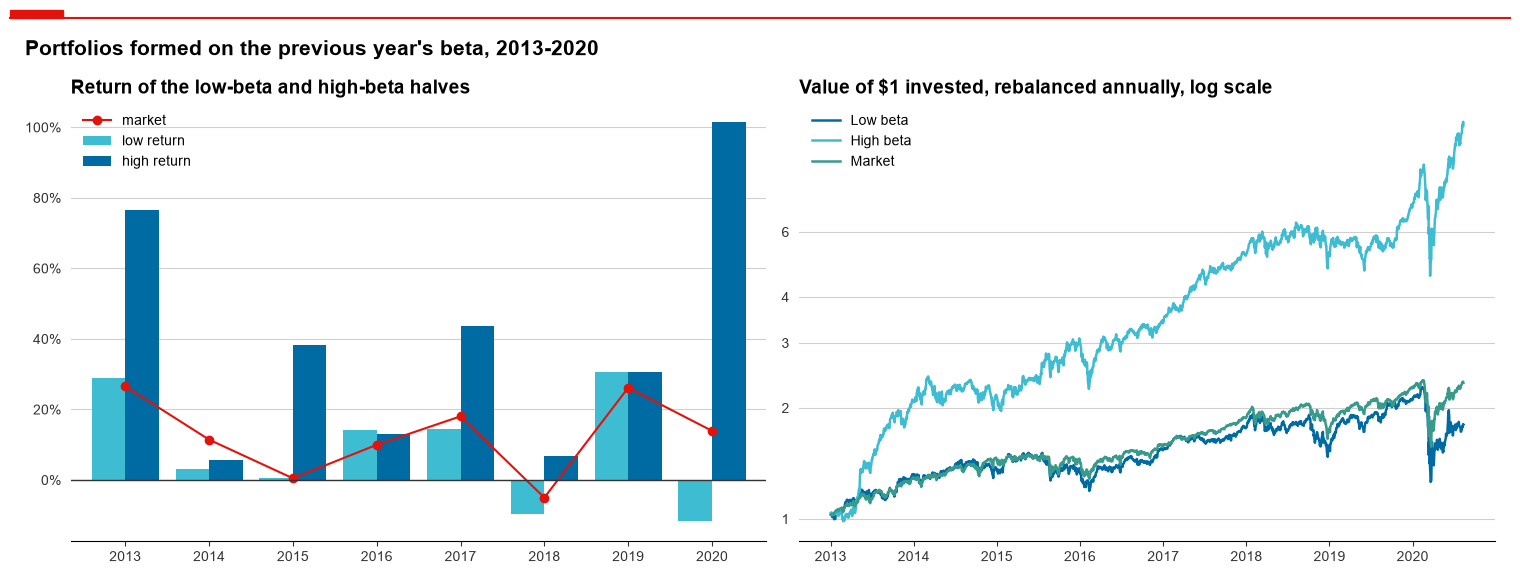

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

bab_summary[["low return", "high return"]].plot.bar(ax=axes[0], rot=0, width=0.8,
                                                    color=[ECONOMIST_COLORS[1], ECONOMIST_COLORS[0]])
axes[0].plot(range(len(bab_summary)), bab_summary["market"], color=ECONOMIST_RED, marker="o", lw=1.5, label="market")
axes[0].axhline(0, color="#333333", lw=1)
axes[0].set_title("Return of the low-beta and high-beta halves")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend()

axes[1].plot((1 + bab_daily).cumprod(), lw=1.8)
axes[1].set_yscale("log")
axes[1].set_yticks([1, 2, 3, 4, 6], labels=["1", "2", "3", "4", "6"])
axes[1].minorticks_off()
axes[1].set_title("Value of $1 invested, rebalanced annually, log scale")
axes[1].legend(bab_daily.columns, loc="upper left")

for ax in axes:
    ax.grid(False, axis="x")

fig.suptitle("Portfolios formed on the previous year's beta, 2013-2020", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

### 3.2 Sensitivity to the estimation window
The test is repeated with 126-day, 252-day and 504-day estimation windows, and once excluding Tesla, whose alpha dominates the sample.

In [102]:
def test_summary(stock_returns, market_returns, window, label):
    '''Run the yearly test once and summarise it in a single row.'''
    panel = capm_panel(stock_returns, market_returns, years=range(2013, 2021), window=window)
    panel = panel[panel["days used"] >= 0.6 * window]                  # drop years with too little history
    cross_section = cross_sectional_regressions(panel)
    gamma1, gamma0 = cross_section["gamma1 (CAPM: market return)"], cross_section["gamma0 (CAPM: 0)"]

    return {"sample": label, "window (days)": window, "years": panel["year"].nunique(),
            "avg gamma1": gamma1.mean(), "t(gamma1)": gamma1.mean() / gamma1.sem(),
            "avg market return": panel["market return"].mean(), "avg gamma0": gamma0.mean(),
            "mean abs. error": panel["error"].abs().mean()}


pd.DataFrame([test_summary(stock_returns, market_returns, window, "all 8 stocks") for window in (126, 252, 504)] +
             [test_summary(stock_returns.drop(columns="TSLA"), market_returns, window, "without TSLA") for window in (126, 252, 504)]).round(3)

,sample,window (days),years,avg gamma1,t(gamma1),avg market return,avg gamma0,mean abs. error
0,all 8 stocks,126,8,0.4350,1.7120,0.1270,-0.2250,0.2690
1,all 8 stocks,252,8,0.4560,2.1620,0.1270,-0.2870,0.2630
2,all 8 stocks,504,7,0.4140,1.8160,0.1070,-0.2820,0.2460
3,without TSLA,126,8,0.3880,2.1760,0.1270,-0.2270,0.2200
4,without TSLA,252,8,0.3500,2.1430,0.1270,-0.2180,0.2160
5,without TSLA,504,7,0.3380,1.9760,0.1070,-0.2330,0.2120


**Comments – Task #3**

**1. Beta estimates are persistent but imprecise.** Consecutive annual estimates correlate 0.65. Apple's moves from 0.63 (2014) to 1.56 (2020) and Amazon's from 1.12 to 1.62, while AT&T remains between 0.48 and 0.78 and MGM does not fall below 1.34. The cross-sectional ordering is therefore reasonably stable while the levels are not, and measurement error in the regressor biases the estimated slope of the security market line towards zero.

**2. The estimated relation has the predicted sign but not the predicted magnitude.** Pooling the 64 stock-years gives $\bar r_i^{\,y} = -0.35 + 0.53\,\beta_i^{\,y-1}$ with $R^2 = 0.14$, and the Fama-MacBeth estimates are $\gamma_1 = 0.46$ ($t = 2.16$) and $\gamma_0 = -0.29$, against the theoretical values $\gamma_1 = \bar r_M = 0.127$ and $\gamma_0 = 0$. The compensation per unit of beta is thus about four times the market risk premium, and the intercept differs from zero. The estimates are stable across windows (0.34 to 0.46) and are not driven by Tesla. The pooled $t$ of 3.21 treats the 64 observations as independent although the eight stocks share a common shock each year; the Fama-MacBeth average, which corresponds to clustering by year, is the appropriate statistic.

**3. Annual cross-sections have little explanatory power.** One of the eight slopes is significant at the 10% level (2013), the annual $R^2$ ranges from 0.00 to 0.47, and the slope is negative in 2014 and 2019. The mean absolute forecast error is 26.3% p.a., against 27.0% for the naive forecast that assigns the market return to every stock. Given residual volatilities of 16% to 50% (§2.2), the spread in betas, worth roughly 8 pp of expected return per year, is small relative to the noise.

**4. The pricing errors are systematic rather than random.** Tesla exceeds its predicted return by 55 pp per year on average, Amazon by 24 pp and Apple by 15 pp, while IBM falls short by 14 pp and AT&T by 9 pp. Each sign matches the corresponding full-sample alpha of §2.1. Persistent asset-specific errors are more consistent with an omitted factor than with estimation noise, and the ordering corresponds to the growth-value distinction of Fama and French.

**5. The low-beta anomaly is not observed in this sample.** The high-beta half returns 36.3% p.a. at 28.2% volatility (Sharpe ratio 1.29), against 9.9% at 20.5% (0.48) for the low-beta half; the average difference is $-30.7$ pp ($t = -2.28$) and is positive in two of eight years. Two considerations qualify this without supporting the model. First, eight stocks are not a representative cross-section: Apple, Amazon, Google and Tesla combine high betas with high alphas, so beta partly proxies for exposure to growth stocks, and the Optional Task recovers a flat relation on 436 stocks. Second, 2020 raises all betas while rewarding precisely those firms (slope 1.66, mean absolute error 61%).

**6. Interpretation.** The quantitative predictions are rejected: the intercept differs from zero and the slope from $\bar r_M$. Both explanations discussed in the lecture are consistent with the evidence. A single factor cannot price a cross-section in which growth and value diverge over a decade, and the residual correlations of §2.2 identify an omitted factor directly. In addition, leverage-constrained investors may bid up high-beta securities and flatten the relation at the level of the whole market, as in Frazzini and Pedersen (2014). For portfolio construction, the implication is that beta is informative about risk and considerably less informative about expected return.

## Optional Task – The same test on the full cross-section
The test of Task #3 is repeated on the 436 constituents with a complete price history, using the data obtained above.

In [103]:
# The test of Task #3, repeated on the full cross-section
complete = index_prices.dropna(axis=1)
index_returns, index_market = complete.pct_change().dropna().align(market_returns, join="inner", axis=0)

index_betas = index_returns.apply(lambda r: estimate_beta(r, index_market))
index_means = index_returns.mean() * DAYS
deciles = pd.qcut(index_betas, 10, labels=range(1, 11))

rows = []
for decile, group in index_betas.groupby(deciles, observed=True):
    portfolio = index_returns[group.index].mean(axis=1)                                  # equally weighted decile
    rows.append({"decile": decile, "stocks": len(group), "beta": group.mean(),
                 "return p.a.": portfolio.mean() * DAYS,
                 "volatility p.a.": portfolio.std() * np.sqrt(DAYS),
                 "Sharpe ratio": portfolio.mean() * np.sqrt(DAYS) / portfolio.std()})
decile_table = pd.DataFrame(rows).set_index("decile")

cross_section_fit = ols(index_means, index_betas)
intercept, slope = cross_section_fit.params
print(f"Cross-section of {len(index_betas)} stocks, 2012-2020")
print(f"  fitted    : return = {intercept:.1%} + {slope:.1%} x beta   "
      f"(t = {cross_section_fit.tvalues[1]:.2f}, p = {cross_section_fit.pvalues[1]:.2f}, R2 = {cross_section_fit.rsquared:.3f})")
print(f"  CAPM says : return = 0.0% + {index_market.mean() * DAYS:.1%} x beta")
decile_table.round(3)

Cross-section of 436 stocks, 2012-2020
  fitted    : return = 16.0% + 2.1% x beta   (t = 1.21, p = 0.23, R2 = 0.003)
  CAPM says : return = 0.0% + 12.5% x beta


,stocks,beta,return p.a.,volatility p.a.,Sharpe ratio
decile,,,,,
1,44,0.5820,0.1610,0.1320,1.2220
2,44,0.7590,0.1570,0.1430,1.0960
3,43,0.8530,0.1900,0.1510,1.2580
4,44,0.9310,0.1890,0.1630,1.1580
5,43,0.9880,0.1800,0.1710,1.0540
6,44,1.0590,0.2020,0.1840,1.0930
7,43,1.1240,0.1940,0.1970,0.9870
8,44,1.1940,0.1780,0.2110,0.8430
9,43,1.2930,0.1900,0.2320,0.8170


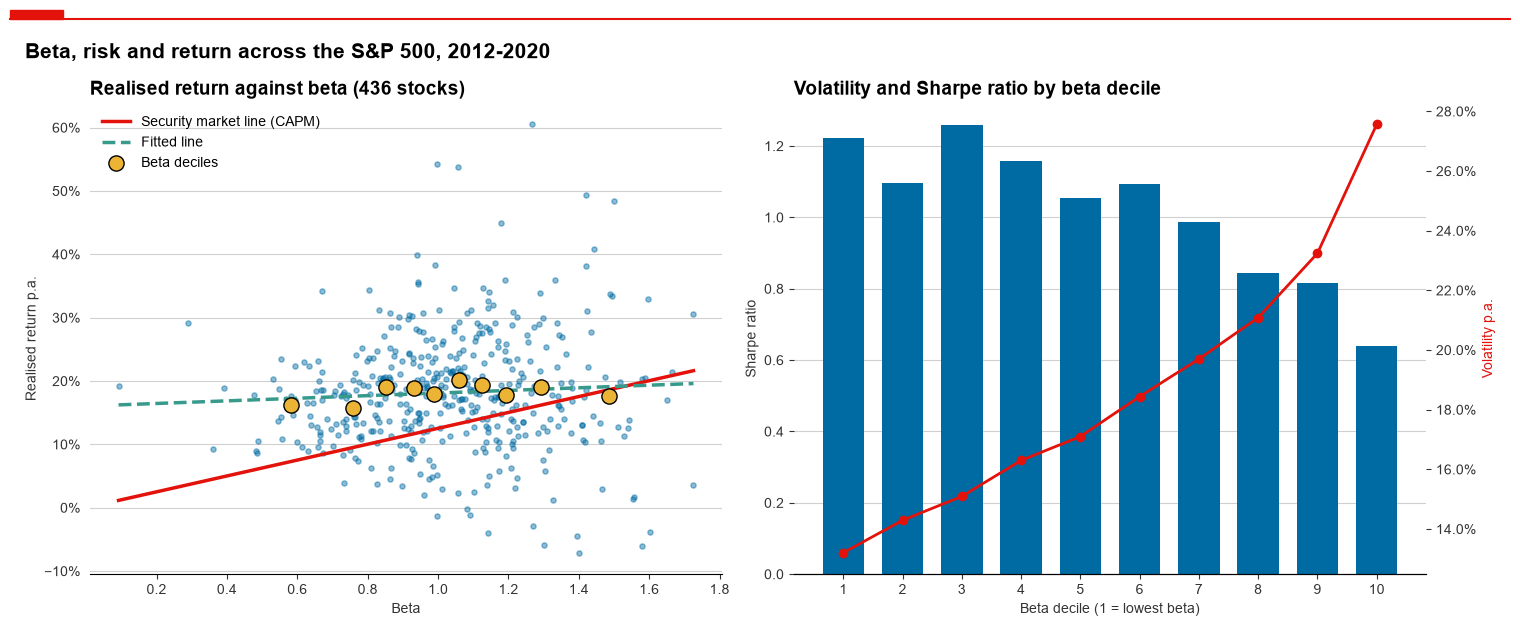

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
grid = np.linspace(index_betas.min(), index_betas.max(), 20)

axes[0].scatter(index_betas, index_means, s=14, alpha=0.45, color=ECONOMIST_COLORS[0])
axes[0].plot(grid, RF + grid * (index_market.mean() * DAYS - RF), color=ECONOMIST_RED, lw=2.5, label="Security market line (CAPM)")
axes[0].plot(grid, intercept + slope * grid, color=ECONOMIST_COLORS[2], lw=2.5, ls="--", label="Fitted line")
axes[0].scatter(decile_table["beta"], decile_table["return p.a."], s=120, color=ECONOMIST_COLORS[3],
                edgecolors="black", zorder=4, label="Beta deciles")
axes[0].set_xlabel("Beta")
axes[0].set_ylabel("Realised return p.a.")
axes[0].set_title(f"Realised return against beta ({len(index_betas)} stocks)")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend(loc="upper left")

axes[1].bar(decile_table.index.astype(str), decile_table["Sharpe ratio"], color=ECONOMIST_COLORS[0], width=0.7)
volatility_axis = axes[1].twinx()
volatility_axis.plot(decile_table.index.astype(str), decile_table["volatility p.a."], color=ECONOMIST_RED, marker="o", lw=2)
volatility_axis.set_ylabel("Volatility p.a.", color=ECONOMIST_RED)
volatility_axis.yaxis.set_major_formatter(PercentFormatter(1))
volatility_axis.grid(False)
axes[1].set_xlabel("Beta decile (1 = lowest beta)")
axes[1].set_ylabel("Sharpe ratio")
axes[1].set_title("Volatility and Sharpe ratio by beta decile")

for ax in axes:
    ax.grid(False, axis="x")

fig.suptitle("Beta, risk and return across the S&P 500, 2012-2020", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

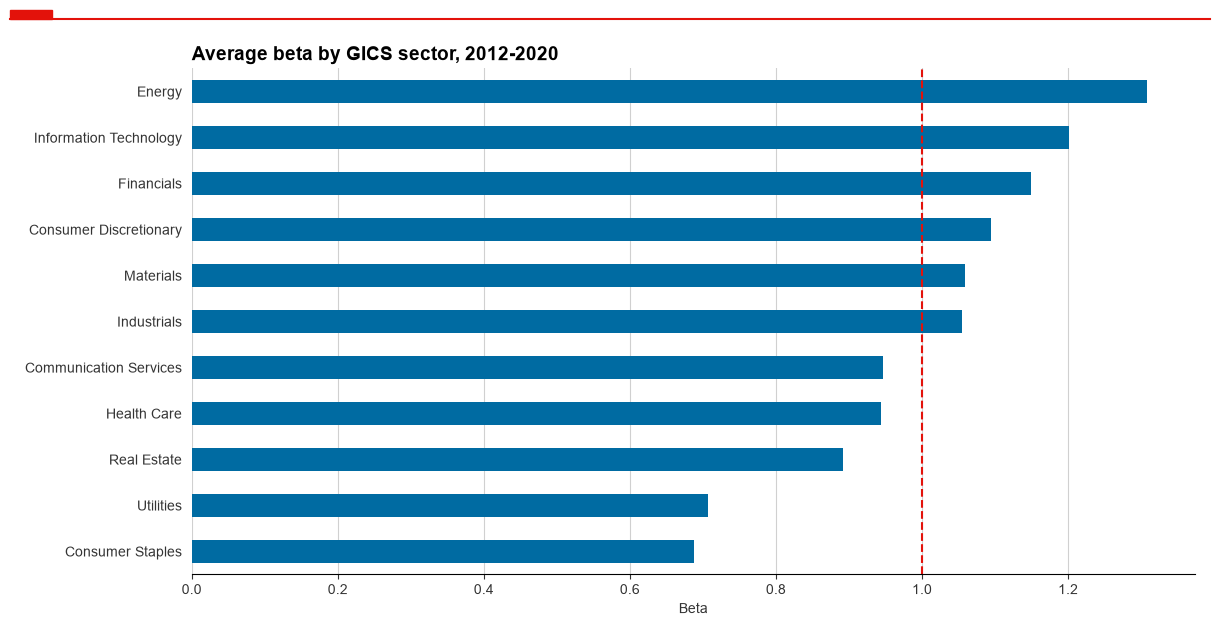

,stocks,beta,return p.a.
GICS Sector,,,
Consumer Staples,31,0.6880,0.1600
Utilities,29,0.7070,0.1330
Real Estate,28,0.8920,0.1360
Health Care,53,0.9440,0.2190
Communication Services,16,0.9460,0.2090
Industrials,70,1.0550,0.1890
Materials,22,1.0590,0.1540
Consumer Discretionary,42,1.0940,0.1970
Financials,69,1.1490,0.1730


In [105]:
sector_table = (pd.DataFrame({"beta": index_betas, "return p.a.": index_means})
                .join(constituents.set_index("Symbol")["GICS Sector"])
                .groupby("GICS Sector").agg(stocks=("beta", "size"), beta=("beta", "mean"), **{"return p.a.": ("return p.a.", "mean")})
                .sort_values("beta"))

ax = sector_table["beta"].plot.barh(figsize=(12, 6), color=ECONOMIST_COLORS[0])
ax.axvline(1, color=ECONOMIST_RED, lw=1.5, ls="--")
ax.set_title("Average beta by GICS sector, 2012-2020")
ax.set_xlabel("Beta")
ax.set_ylabel("")
ax.grid(False, axis="y")
ax.grid(True, axis="x", color="#D0D0D0")
show()

sector_table.round(3)

**Comments – Optional Task**
- On 436 stocks the estimated relation is almost flat: $\bar r_i = 16.0\% + 2.1\%\,\beta_i$ ($t = 1.21$, $R^2 = 0.003$), against the theoretical $0\% + 12.5\%\,\beta_i$. The corresponding slope on the eight stocks of Task #3 is 0.53, which suggests that the steeper relation there reflects sample selection; the familiar empirical failure of the model appears once the cross-section approximates the market.
- The decile results correspond to the evidence in Frazzini and Pedersen (2014). From the lowest to the highest decile, average beta rises from 0.58 to 1.49 and volatility from 13.2% to 27.6%, while the average return changes little (16.1% to 17.6%). The Sharpe ratio consequently falls from 1.22 to 0.64. Levering the lowest decile by a factor of 2.1 to the volatility of the highest would have yielded 33.7% p.a. at comparable risk, against 17.6%; implementing this requires the leverage and short-selling capacity that many mandates do not permit, which is the explanation offered for the persistence of the anomaly.
- Sector betas are economically plausible: Consumer Staples (0.69) and Utilities (0.71) are defensive, Information Technology (1.20) and Financials (1.15) cyclical. Energy is a counter-example to the model, combining the highest beta (1.31) with the lowest return (6.8% p.a.), as the oil price declines of 2014-16 and 2020 were not compensated in this period.
- Three qualifications apply: survivorship bias raises the intercept, betas estimated on the same window as the returns bias the slope downwards, and 2012-2020 is a single realisation of a rising market. The direction of the result is nevertheless consistent with four decades of published evidence.

## Conclusion
The two components of the conclusion are summarised in one figure. The same stocks and the same beta estimates appear on both axes: on the left, beta against the risk it is intended to measure; on the right, beta against the return it is intended to price.

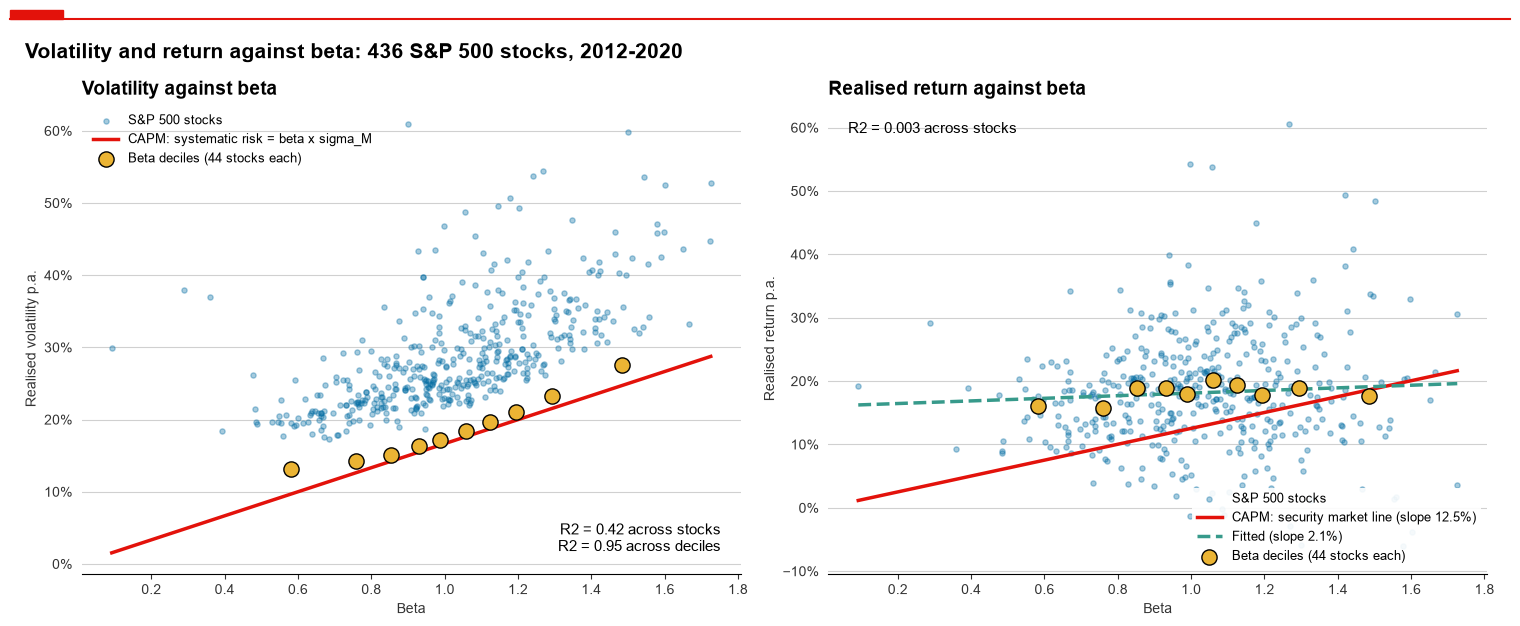

In [106]:
index_volatility = index_returns.std() * np.sqrt(DAYS)
sigma_market, market_mean = index_market.std() * np.sqrt(DAYS), index_market.mean() * DAYS
grid = np.linspace(index_betas.min(), index_betas.max(), 20)

return_fit = ols(index_means, index_betas)
fit_intercept, fit_slope = return_fit.params
r2_return = return_fit.rsquared
r2_risk = ols(index_volatility, index_betas).rsquared
r2_risk_deciles = ols(decile_table["volatility p.a."], decile_table["beta"]).rsquared

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

axes[0].scatter(index_betas, index_volatility, s=14, alpha=0.35, color=ECONOMIST_COLORS[0], label="S&P 500 stocks")
axes[0].plot(grid, grid * sigma_market, color=ECONOMIST_RED, lw=2.5, label="CAPM: systematic risk = beta x sigma_M")
axes[0].scatter(decile_table["beta"], decile_table["volatility p.a."], s=120, color=ECONOMIST_COLORS[3],
                edgecolors="black", zorder=4, label="Beta deciles (44 stocks each)")
axes[0].set_title("Volatility against beta")
axes[0].set_ylabel("Realised volatility p.a.")
axes[0].text(0.97, 0.04, f"R2 = {r2_risk:.2f} across stocks\nR2 = {r2_risk_deciles:.2f} across deciles",
             transform=axes[0].transAxes, ha="right", va="bottom", fontsize=11)
axes[0].legend(loc="upper left", fontsize=9)

axes[1].scatter(index_betas, index_means, s=14, alpha=0.35, color=ECONOMIST_COLORS[0], label="S&P 500 stocks")
axes[1].plot(grid, RF + grid * (market_mean - RF), color=ECONOMIST_RED, lw=2.5, label=f"CAPM: security market line (slope {market_mean:.1%})")
axes[1].plot(grid, fit_intercept + fit_slope * grid, color=ECONOMIST_COLORS[2], lw=2.5, ls="--", label=f"Fitted (slope {fit_slope:.1%})")
axes[1].scatter(decile_table["beta"], decile_table["return p.a."], s=120, color=ECONOMIST_COLORS[3],
                edgecolors="black", zorder=4, label="Beta deciles (44 stocks each)")
axes[1].set_title("Realised return against beta")
axes[1].set_ylabel("Realised return p.a.")
axes[1].text(0.03, 0.96, f"R2 = {r2_return:.3f} across stocks", transform=axes[1].transAxes, va="top", fontsize=11)

axes[1].legend(loc="lower right", fontsize=9, frameon=True, facecolor="white", edgecolor="none", framealpha=0.9)

for ax in axes:
    ax.set_xlabel("Beta")
    ax.yaxis.set_major_formatter(PercentFormatter(1))

    ax.grid(False, axis="x")

fig.suptitle("Volatility and return against beta: 436 S&P 500 stocks, 2012-2020", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

**Left panel.** Volatility increases with beta ($R^2 = 0.42$), and individual stocks lie above the theoretical line by their idiosyncratic risk. Once that component is diversified away, with 44 stocks per decile, the portfolios lie close to $\beta\,\sigma_M$ ($R^2 = 0.95$). The risk decomposition of the model is therefore supported: beta measures the non-diversifiable component and aggregates linearly.

**Right panel.** The same beta estimates account for 0.3% of the cross-sectional variation in returns. The decile portfolios lie between 16% and 20% where the security market line implies 7% to 19%, so the additional risk shown in the left panel was not compensated.

The evidence supports the risk decomposition of the model. Beta measures the share of a stock's risk attributable to the market, it aggregates linearly across a portfolio, and the remainder is diversifiable, which is why MGM and Boeing declined together in March 2020 while AT&T did not.

The pricing relation is not supported. The compensation per unit of beta corresponds to the market risk premium in neither sample, and the pricing errors are associated with firm characteristics, growth against value and technology against energy, rather than with beta. For a portfolio mandate the implication is that an allocation to high-beta securities reliably increases risk and, on the evidence of the full index, lowers the return obtained per unit of it.